<a href="https://colab.research.google.com/github/APMAPM1/Tech-Gadget-Consumption_2015-2025/blob/develop%2Ftech_gadget_consumption/Tech_Gadget_Consumption_(2015_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tech Gadget Consumption (2015 - 2025)**

**Overview**

Technology adoption has been evolving rapidly, shaping industries and consumer behaviors worldwide. This project leverages a dataset covering global gadget consumption trends from 2015 to 2025.

The data encompasses key technologies such as smartphones, laptops, gaming consoles, smartwatches, and the rising adoption of 5G. Your task as an intern will be to apply machine learning techniques to evaluate and forecast trends using the provided dataset.

**Dataset Description**

- Country: Country where data is recorded 🌍
- Year: Year of observation 📅
- Smartphone Sales (Million): Number of smartphones sold (in millions) 📱
- Laptop Shipments (Million): Number of laptops shipped (in millions) 💻
- Gaming Console Adoption (%): Percentage of population using gaming consoles 🎮
- Smartwatch Penetration (%): Percentage of population using smartwatches ⌚
- Avg Consumer Spending ($): Average spending on tech gadgets 💵
- E-Waste Generation (KT): E-waste generated in kilotons (KT) ♻️
- 5G Penetration (%): Percentage of population with 5G access 📡


# **Loading Dataset and data collection**

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [281]:
from google.colab import drive

In [282]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [283]:
file_path = '/content/drive/MyDrive/Datasets/Global_Tech_Gadget_Consumption.csv'

In [284]:
df = pd.read_csv(file_path)
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26


In [285]:
df.columns

Index(['Country', 'Year', 'Smartphone Sales (Millions)',
       'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
       'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)',
       'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'],
      dtype='object')

In [286]:
df.shape

(110, 9)

In [287]:
df.describe()

,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
count,110.00000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,2020.00000,269.095545,86.082000,21.753545,14.129818,1571.539182,1035.352636,42.816273
std,3.17675,128.313552,36.429392,9.748557,6.353190,816.552255,562.591157,21.888573
min,2015.00000,64.000000,20.790000,5.490000,2.040000,220.090000,111.470000,2.990000
25%,2017.00000,156.910000,59.412500,13.737500,8.982500,856.957500,570.250000,23.952500
50%,2020.00000,253.435000,87.450000,20.365000,14.520000,1592.145000,1023.270000,45.735000
75%,2023.00000,376.255000,113.965000,28.460000,19.815000,2195.960000,1487.847500,58.900000
max,2025.00000,499.890000,149.210000,39.470000,24.810000,2989.540000,1962.590000,79.340000


In [288]:
df.describe(include=['object'])

,Country
count,110
unique,10
top,USA
freq,11


In [289]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   110 non-null    object 
 1   Year                                      110 non-null    int64  
 2   Smartphone Sales (Millions)               110 non-null    float64
 3   Laptop Shipments (Millions)               110 non-null    float64
 4   Gaming Console Adoption (%)               110 non-null    float64
 5   Smartwatch Penetration (%)                110 non-null    float64
 6   Average Consumer Spending on Gadgets ($)  110 non-null    float64
 7   E-Waste Generated (Metric Tons)           110 non-null    float64
 8   5G Penetration Rate (%)                   110 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 7.9+ KB


In [290]:
df.nunique()

,0
Country,10
Year,11
Smartphone Sales (Millions),109
Laptop Shipments (Millions),110
Gaming Console Adoption (%),106
Smartwatch Penetration (%),108
Average Consumer Spending on Gadgets ($),110
E-Waste Generated (Metric Tons),110
5G Penetration Rate (%),110


# **Data Preparation**

In [291]:
df.isnull().sum()

,0
Country,0
Year,0
Smartphone Sales (Millions),0
Laptop Shipments (Millions),0
Gaming Console Adoption (%),0
Smartwatch Penetration (%),0
Average Consumer Spending on Gadgets ($),0
E-Waste Generated (Metric Tons),0
5G Penetration Rate (%),0


In [292]:
df.duplicated().sum()

np.int64(0)

## **Data Insights**

Overall Insights

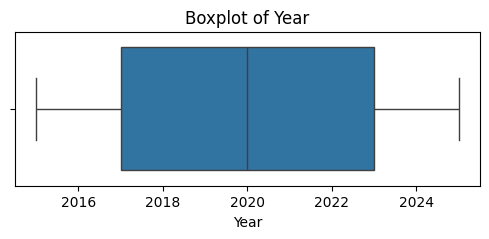

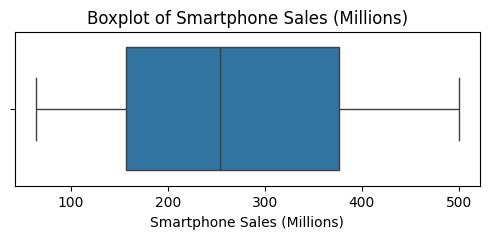

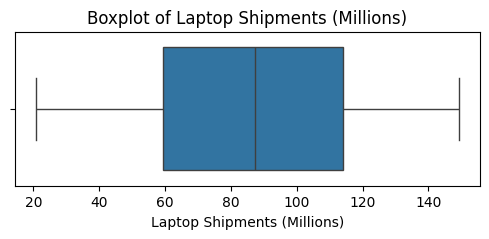

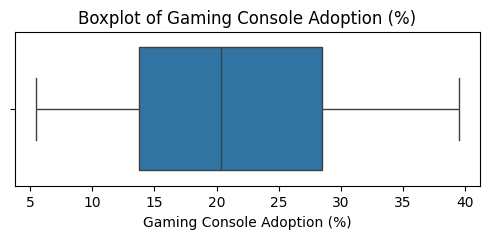

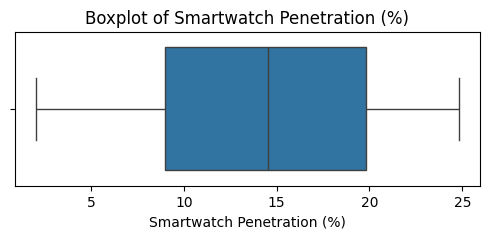

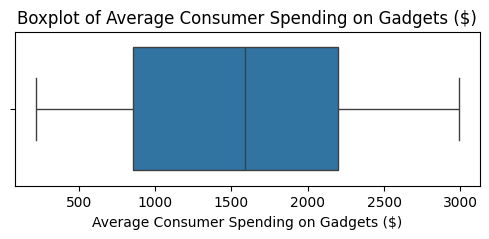

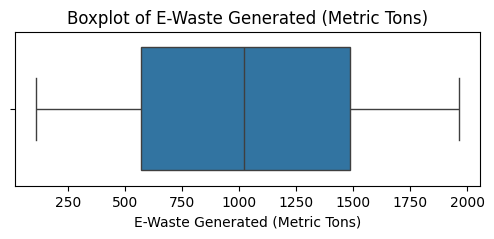

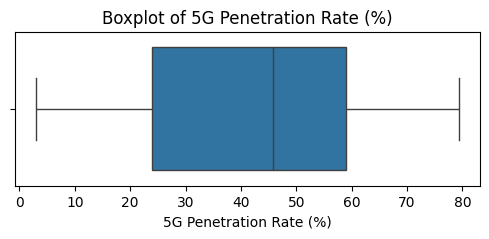

In [293]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
for col in numerical_cols:
  plt.figure(figsize=(6, 2))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-294-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

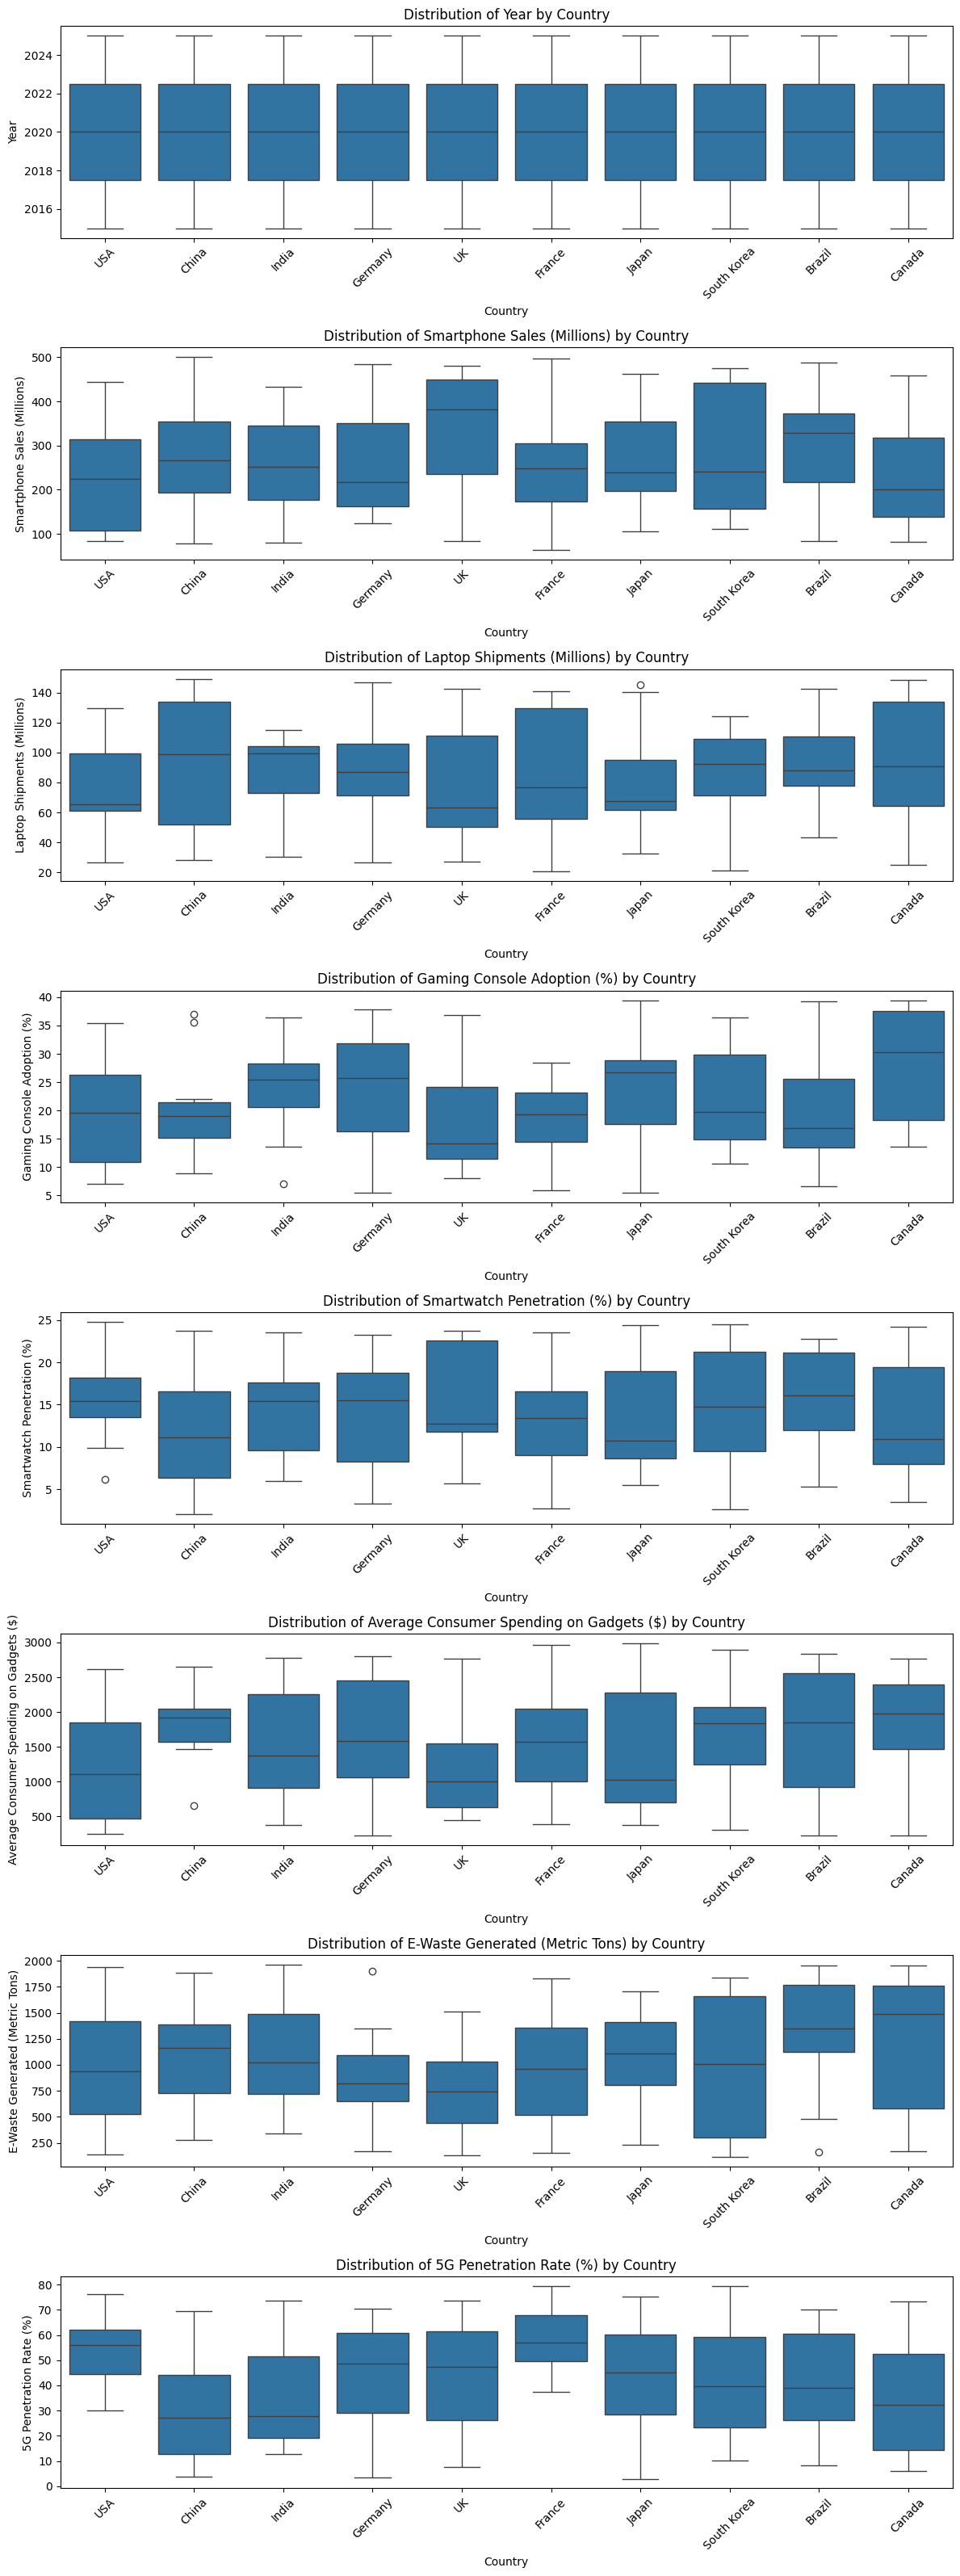

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Set up the figure size dynamically
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=1, figsize=(12, len(numerical_columns) * 4))

# If there's only one numerical column, make axes iterable
if len(numerical_columns) == 1:
    axes = [axes]

# Generate boxplots for each numerical column
for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x="Country", y=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by Country")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)  # Rotate x-axis labels

plt.tight_layout()
plt.show()


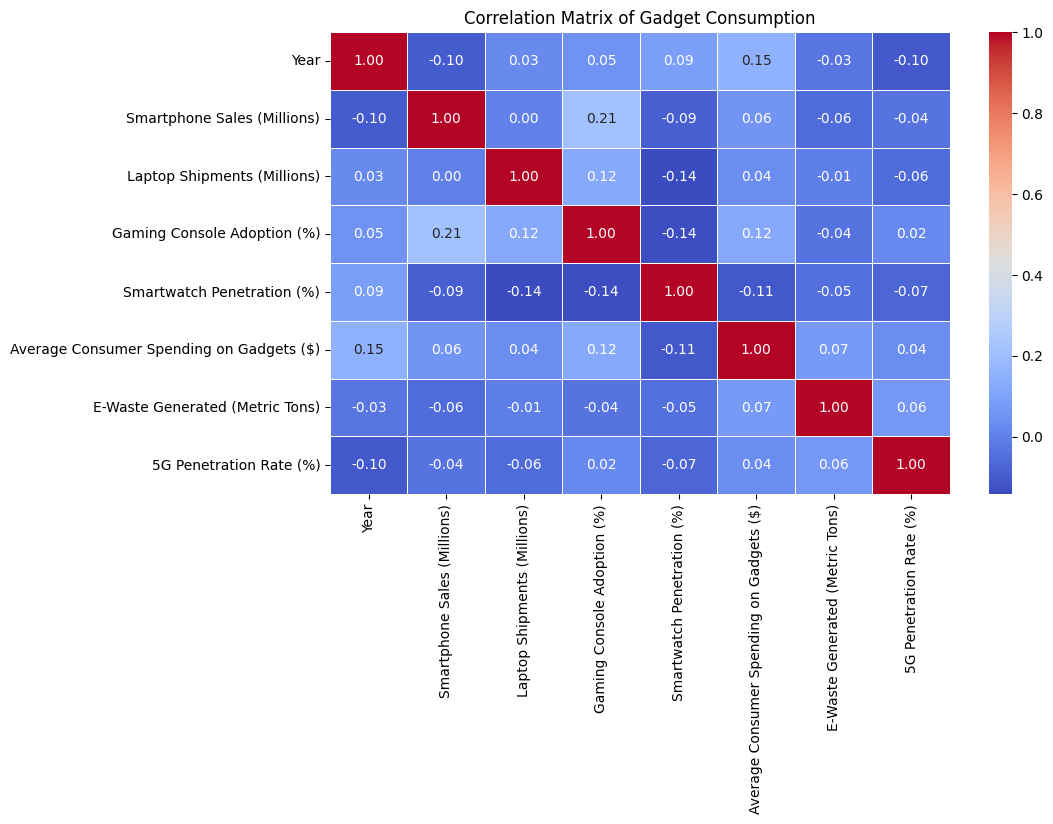

In [295]:
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Gadget Consumption")
plt.show()

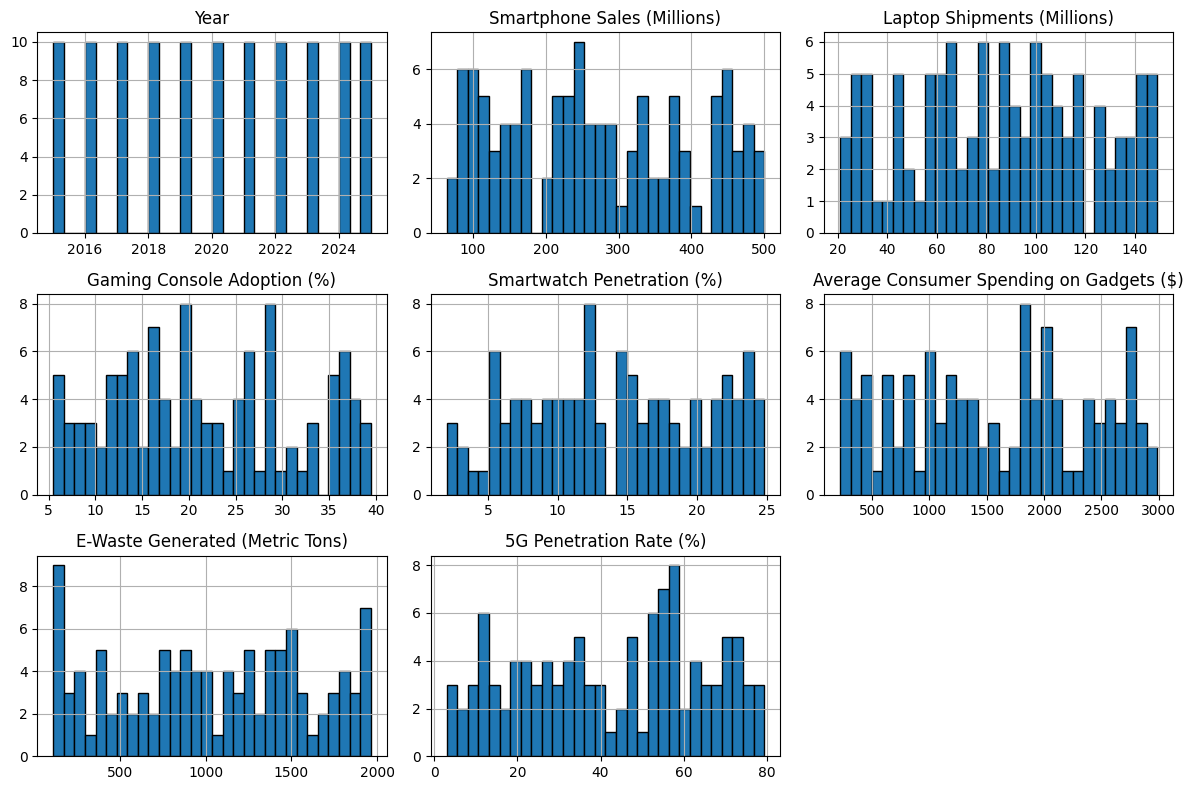

In [296]:
df.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

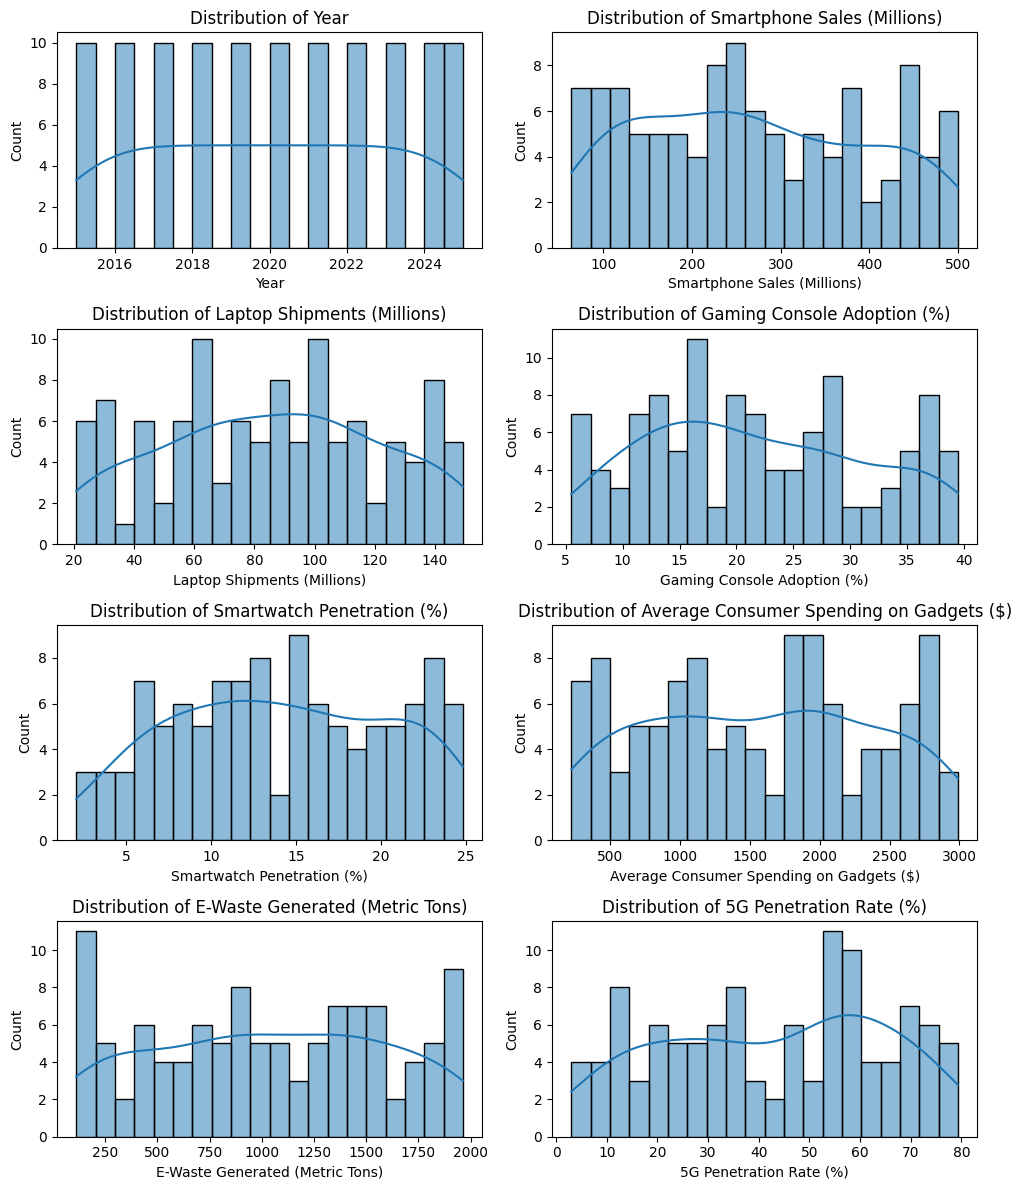

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get all numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Determine the number of rows and columns dynamically
num_cols = len(numerical_columns)
num_rows = (num_cols // 2) + (num_cols % 2)  # Adjust row count for odd numbers

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(10, num_rows * 3))
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Plot histograms
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


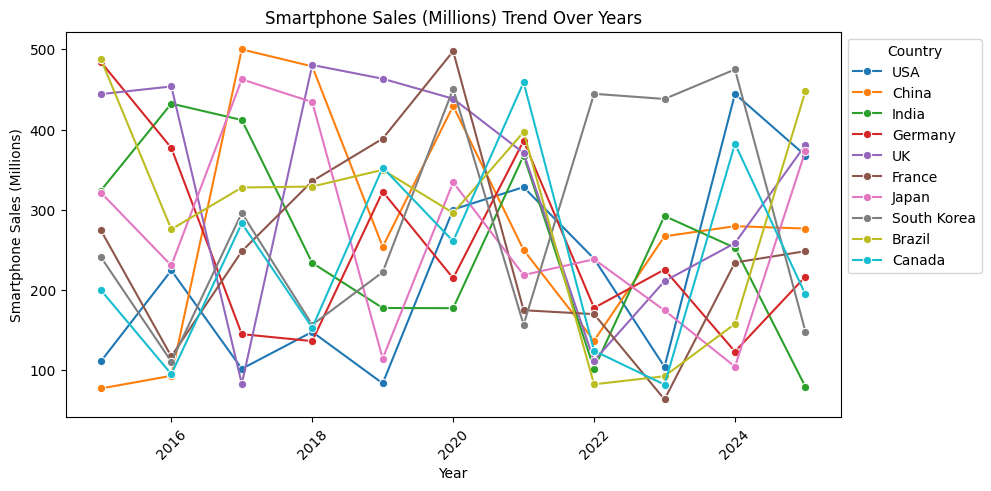

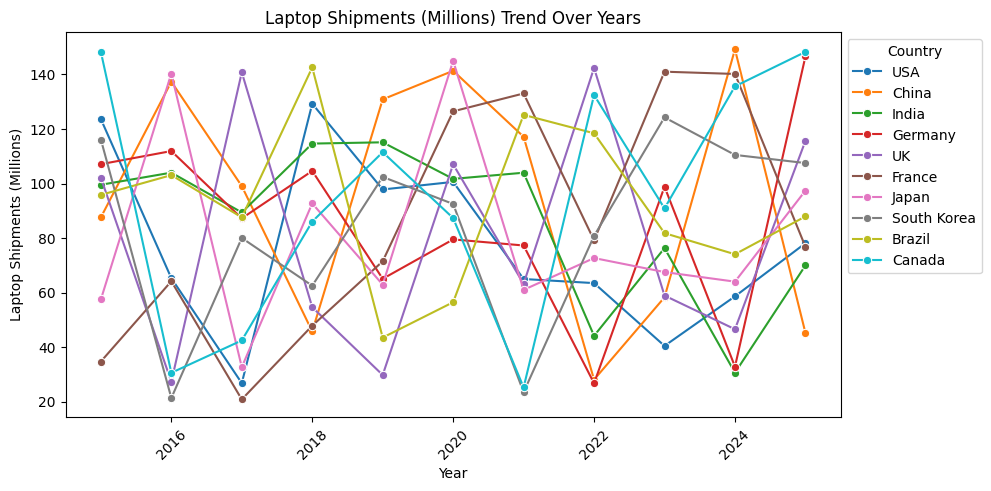

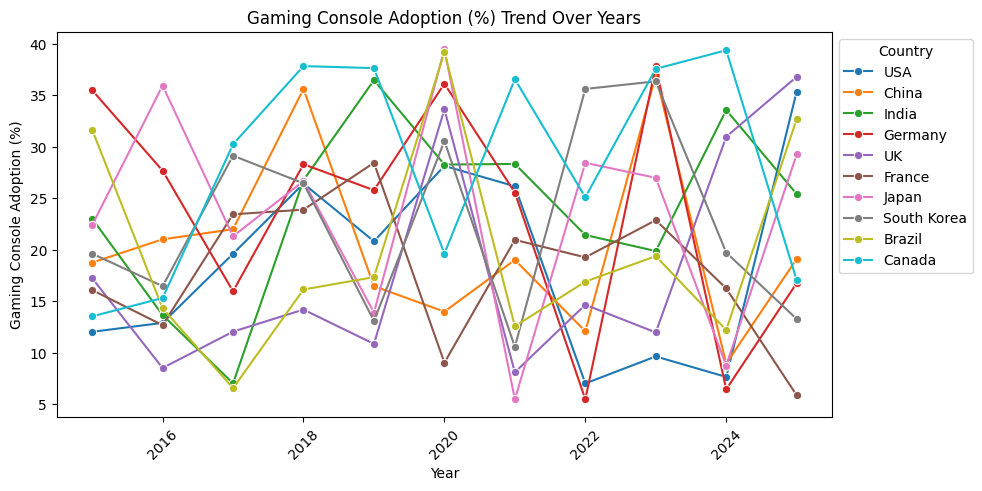

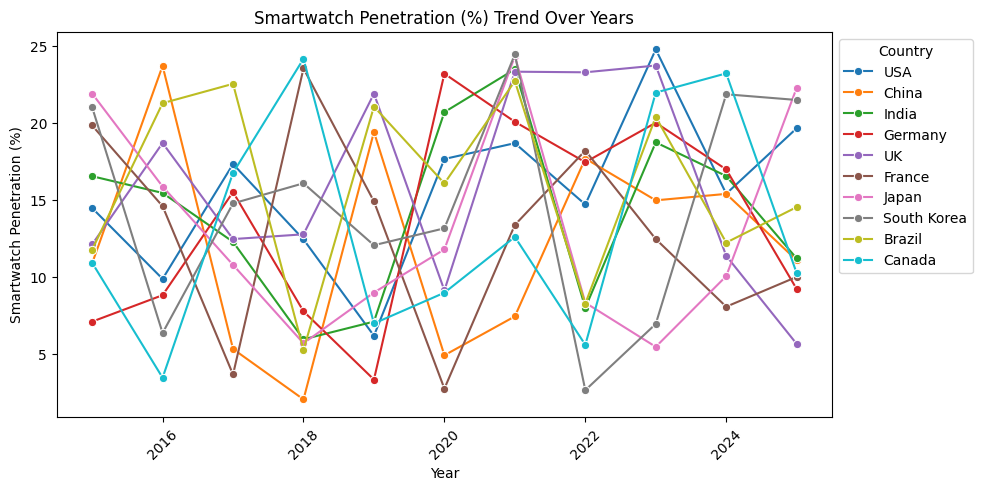

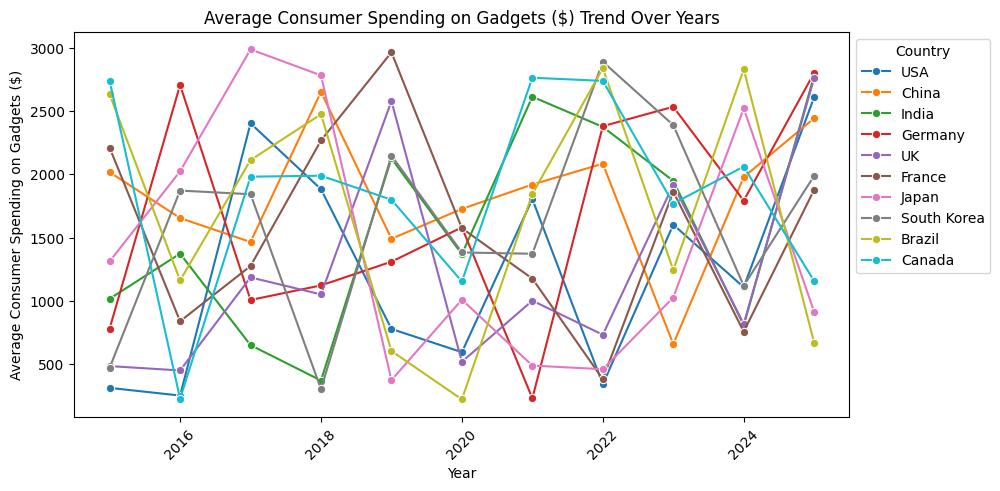

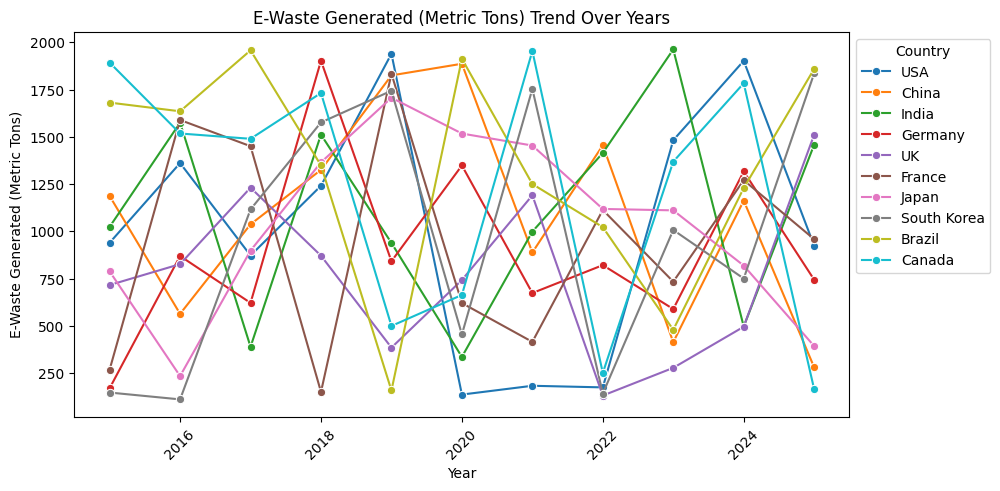

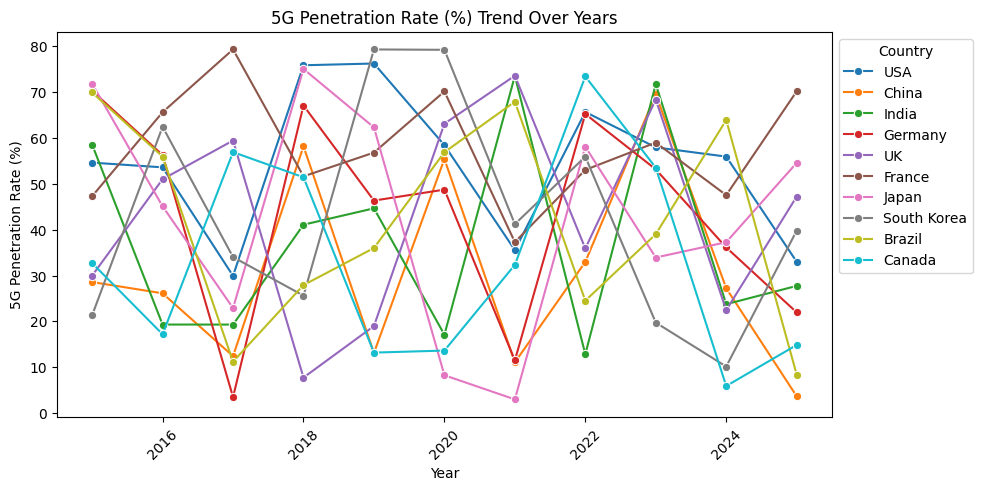

In [298]:
columns_to_plot = [
    "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)",
    "Average Consumer Spending on Gadgets ($)",
    "E-Waste Generated (Metric Tons)",
    "5G Penetration Rate (%)"

]

if "Year" in df.columns:
    for col in columns_to_plot:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            sns.lineplot(x="Year", y=col, data=df, hue="Country", marker="o")
            plt.title(f"{col} Trend Over Years")
            plt.xlabel("Year")
            plt.ylabel(f"{col}")
            plt.xticks(rotation=45)
            plt.legend(title="Country", bbox_to_anchor=(1, 1))
            plt.show()


In [299]:
tech_cols = ['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)',
            'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)',
             'Average Consumer Spending on Gadgets ($)', 'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)']

df_tech = df.groupby('Country')[tech_cols].mean().sort_values(by='Smartphone Sales (Millions)', ascending=False)

df_tech.style.background_gradient(cmap='Blues')

,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
Country,,,,,,,
UK,336.145455,80.740000,18.109091,15.874545,1227.135455,762.036364,43.448182
Brazil,295.027273,92.397273,19.924545,16.030000,1694.451818,1321.446364,41.980909
South Korea,285.612727,83.754545,22.823636,14.639091,1616.678182,967.315455,42.629091
China,276.717273,94.526364,20.375455,12.089091,1827.165455,1093.421818,30.766364
Japan,273.532727,81.231818,23.523636,13.239091,1445.444545,1037.119091,42.949091
India,259.336364,86.298182,24.000909,14.196364,1585.019091,1100.693636,37.246364
Germany,255.564545,85.233636,23.780000,13.600909,1659.245455,900.139091,43.666364
France,250.460909,85.056364,18.090000,12.866364,1562.700909,946.116364,58.003636
Canada,235.370000,94.412727,28.183636,13.183636,1853.297273,1210.844545,33.202727


Individual Columns

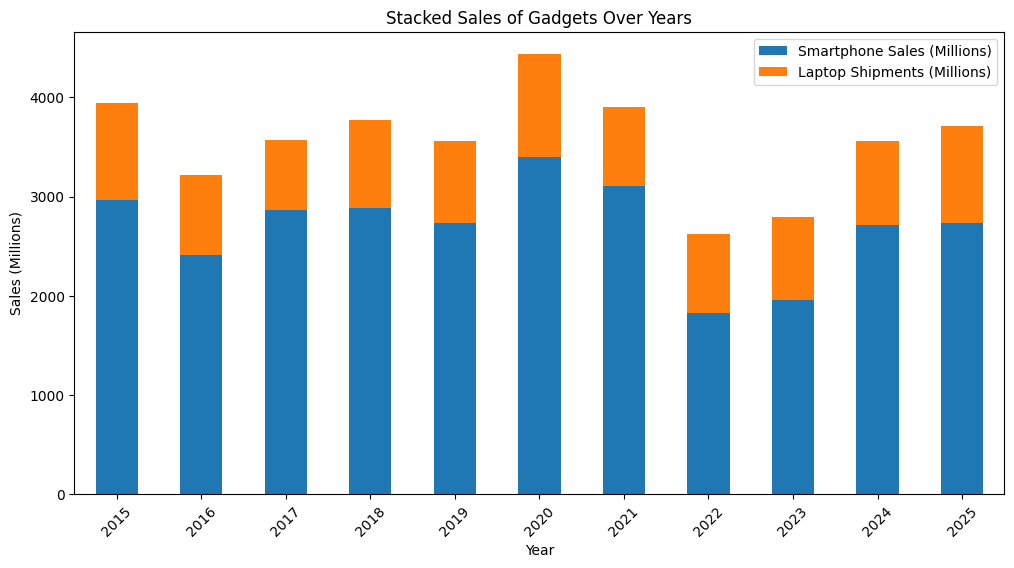

In [300]:
df_grouped = df.groupby("Year")[["Smartphone Sales (Millions)", "Laptop Shipments (Millions)"]].sum()

df_grouped.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Stacked Sales of Gadgets Over Years")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

In [301]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Smartphone Sales (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Smartphone Sales by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [302]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Laptop Shipments (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Laptop Shipments by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [303]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Gaming Console Adoption Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Gaming Console Adoption (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Gaming Console Adoption by Country Over Time",
                     color_continuous_scale="viridis")
fig.show()



In [304]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Smartwatch Penetration Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Smartwatch Penetration (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Smartwatch Penetration by Country Over Time",
                     color_continuous_scale="plasma")
fig.show()


In [305]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Average Consumer Spending on Gadgets ($)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="Average Consumer Spending on Gadgets by Country Over Time",
                    color_continuous_scale="blues")

fig.show()


In [306]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="E-Waste Generated (Metric Tons)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="E-Waste Generation by Country Over Time",
                    color_continuous_scale="reds")

fig.show()


In [307]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="5G Penetration Rate (%)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="5G Penetration Rate by Country Over Time",
                    color_continuous_scale="plasma")

fig.show()


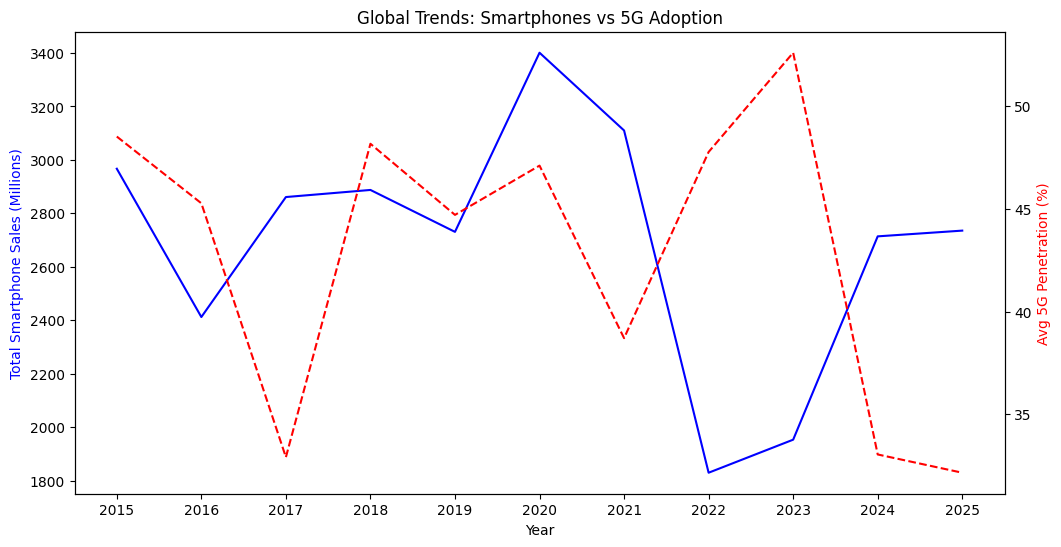

In [308]:
yearly = df.groupby('Year').agg({
    'Smartphone Sales (Millions)': 'sum',
    '5G Penetration Rate (%)': 'mean',
    'E-Waste Generated (Metric Tons)': 'sum'
})

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(yearly.index, yearly['Smartphone Sales (Millions)'], 'b-')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Smartphone Sales (Millions)', color='b')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['5G Penetration Rate (%)'], 'r--')
ax2.set_ylabel('Avg 5G Penetration (%)', color='r')

plt.title("Global Trends: Smartphones vs 5G Adoption")
plt.show()

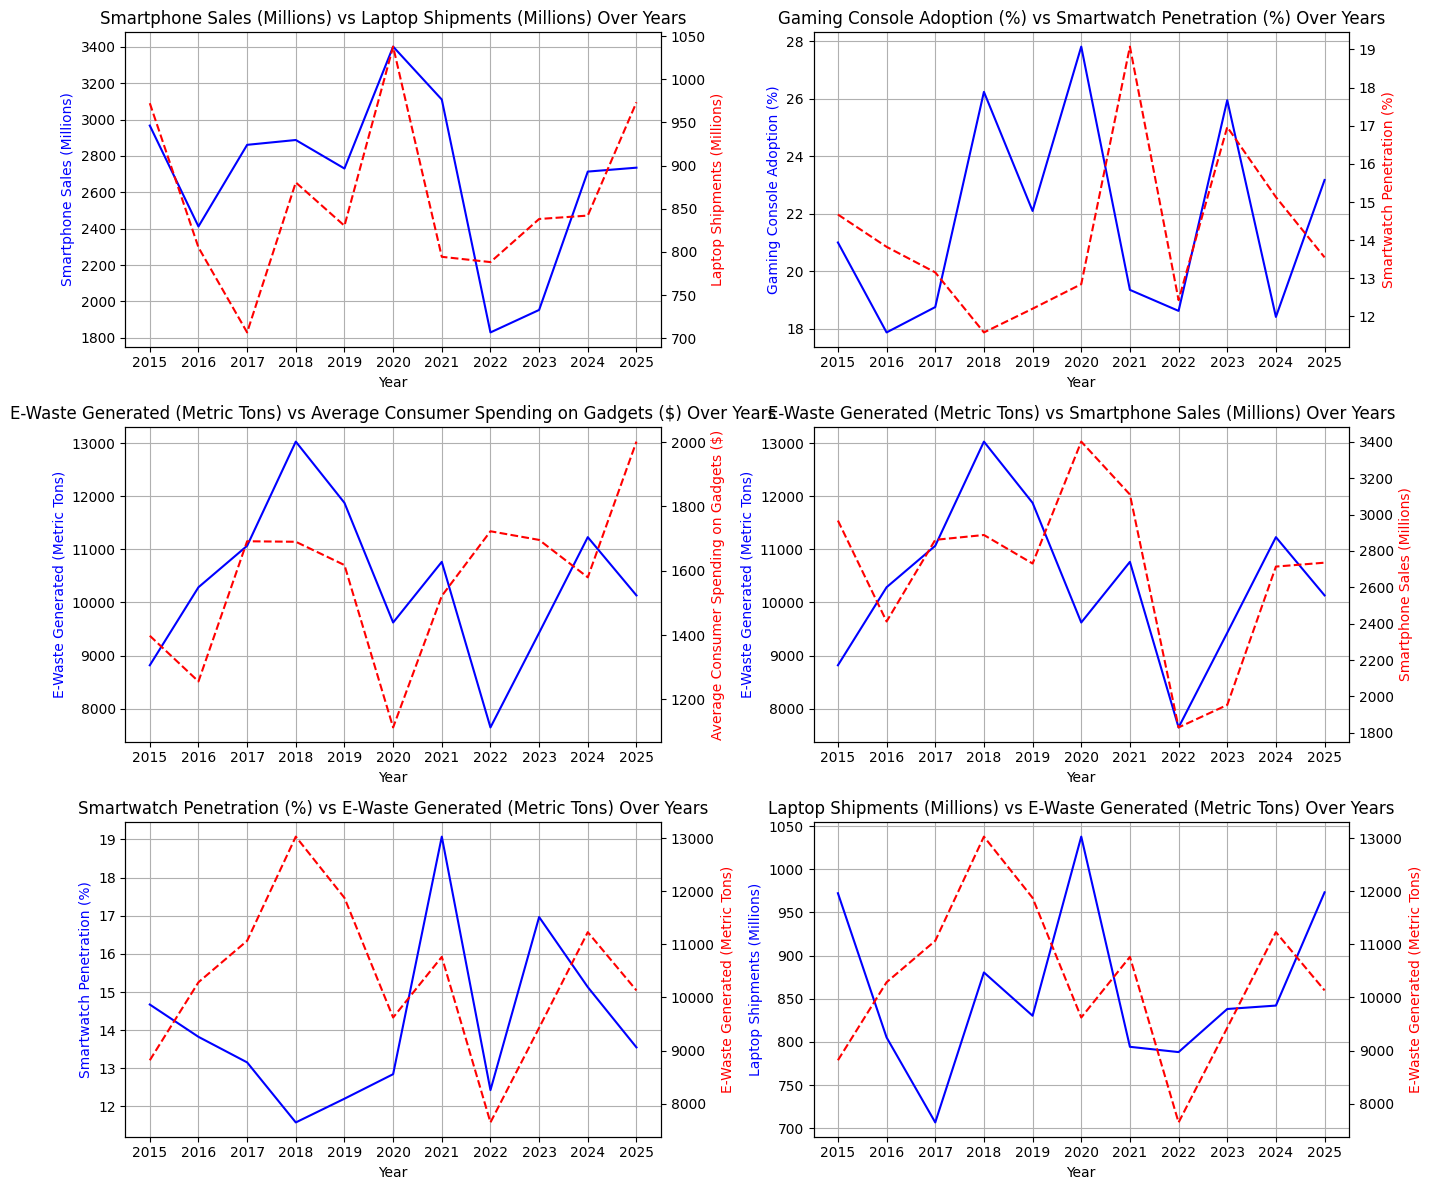

In [309]:
import matplotlib.pyplot as plt

# Group data by Year
yearly = df.groupby('Year').agg({
    'Smartphone Sales (Millions)': 'sum',
    'Laptop Shipments (Millions)': 'sum',
    'Gaming Console Adoption (%)': 'mean',
    'Smartwatch Penetration (%)': 'mean',
    '5G Penetration Rate (%)': 'mean',
    'Average Consumer Spending on Gadgets ($)': 'mean',
    'E-Waste Generated (Metric Tons)': 'sum'
})

# Define column pairs for dual-axis plotting
column_pairs = [
    ('Smartphone Sales (Millions)', 'Laptop Shipments (Millions)'),
    ('Gaming Console Adoption (%)', 'Smartwatch Penetration (%)'),
    ('E-Waste Generated (Metric Tons)', 'Average Consumer Spending on Gadgets ($)'),
    ('E-Waste Generated (Metric Tons)', 'Smartphone Sales (Millions)'),
    ('Smartwatch Penetration (%)', 'E-Waste Generated (Metric Tons)'),
    ('Laptop Shipments (Millions)', 'E-Waste Generated (Metric Tons)')
]

# Plot each pair
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten for easier iteration

for i, (col1, col2) in enumerate(column_pairs):
    ax1 = axes[i]
    ax2 = ax1.twinx()  # Create secondary y-axis

    # Plot first column (e.g., Sales, Shipments, etc.)
    ax1.plot(yearly.index, yearly[col1], 'b-', label=col1)
    ax1.set_xlabel('Year')
    ax1.set_ylabel(col1, color='b')

    # Plot second column (e.g., Adoption %, Spending, etc.)
    ax2.plot(yearly.index, yearly[col2], 'r--', label=col2)
    ax2.set_ylabel(col2, color='r')

    ax1.set_title(f"{col1} vs {col2} Over Years")
    ax1.grid(True)

plt.tight_layout()
plt.show()


In [310]:
df['Year'] = pd.to_numeric(df['Year'])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country_Num'] = le.fit_transform(df['Country'])


Market Research & Consumer Behavior Analysis

In [311]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.Series(
    [variance_inflation_factor(df.select_dtypes(include=np.number).values, i)
     for i in range(df.select_dtypes(include=np.number).shape[1])],
    index=df.select_dtypes(include=np.number).columns
)
print(vif.sort_values())

Country_Num                                  3.963626
E-Waste Generated (Metric Tons)              4.660455
Average Consumer Spending on Gadgets ($)     5.088742
5G Penetration Rate (%)                      5.102846
Smartphone Sales (Millions)                  5.772388
Smartwatch Penetration (%)                   6.355273
Gaming Console Adoption (%)                  6.604327
Laptop Shipments (Millions)                  6.993193
Year                                        40.347870
dtype: float64


Forecasting Future Tech Trends

In [312]:
from statsmodels.tsa.arima.model import ARIMA

# Select a country for forecasting
country = "USA"
usa_data = df[df['Country'] == country].set_index('Year')

# Fit ARIMA model to 5G penetration
model = ARIMA(usa_data['5G Penetration Rate (%)'], order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=5)  # Predict next 5 years
print(forecast)


11    54.198853
12    54.262747
13    54.262940
14    54.262940
15    54.262940
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_mod

In [313]:
# Use Case 1: Forecasting Tech Gadget Consumption
df['Total_Gadget_Sales'] = df['Smartphone Sales (Millions)'] + df['Laptop Shipments (Millions)']
df['Gadget_Growth_Rate'] = df.groupby('Country')['Total_Gadget_Sales'].pct_change()
# Measures year-over-year percentage change in gadget sales per country.
df['device_preference_index'] = ( 0.4 * df['Smartphone Sales (Millions)'] + 0.3 * df['Laptop Shipments (Millions)'] + 0.2 * df['Gaming Console Adoption (%)'] +
    0.1 * df['Smartwatch Penetration (%)'] )
# Composite score showing which devices consumers prefer.
df['spending_per_tech_unit'] = ( df['Average Consumer Spending on Gadgets ($)'] / (df['Smartphone Sales (Millions)'] + df['Laptop Shipments (Millions)'] + 1))
# Average spending per "unit" sold (smartphones + laptops).

# Use Case 2: Identifying Key Factors Affecting Gadget Consumption
df['5G_Impact_Score'] = ( df['5G Penetration Rate (%)'] * df['Smartphone Sales (Millions)'])
# Estimates how much 5G may influence phone sales.
# Smoothes out YoY growth by dividing by the country’s own variability.
df['5g_adoption_momentum'] = ( 0.5 * df.groupby('Country')['5G Penetration Rate (%)'].shift(1) + 0.3 * df.groupby('Country')['5G Penetration Rate (%)'].shift(2) +
    0.2 * df.groupby('Country')['5G Penetration Rate (%)'].shift(3))

# Use Case 3: Understanding Regional Differences in Tech Adoption
df['Regional_Adoption_Score'] = df[[ 'Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Smartwatch Penetration (%)', '5G Penetration Rate (%)']].mean(axis=1)# Composite regional adoption index.
df['ewaste_intensity'] = ( df['E-Waste Generated (Metric Tons)'] / (df['Average Consumer Spending on Gadgets ($)'] / 100))
# E-waste per $100 of consumer spending.
df['device_turnover_index'] = ( (df['Smartphone Sales (Millions)'] / df.groupby('Country')['Smartphone Sales (Millions)'].shift(1)) +
    (df['Laptop Shipments (Millions)'] / df.groupby('Country')['Laptop Shipments (Millions)'].shift(1)))
# Shows how fast people are replacing devices.
df['sustainable_tech_score'] = ( 1 / (df['ewaste_intensity'] + 0.01) *  # Avoid division by zero
    df['5G Penetration Rate (%)']          # Newer tech tends to be more efficient
)
# Combines efficiency and e-waste impact.

# Use Case 4: Optimizing Business Strategies for Tech Companies
df['Revenue_per_Gadget'] = df['Average Consumer Spending on Gadgets ($)'] / df['Total_Gadget_Sales']
# How much revenue you make per gadget sold.
df['5g_s_curve_position'] = ( df['5G Penetration Rate (%)'] /
    (100 - df['5G Penetration Rate (%)'] + 0.01)  # Logistic growth model
)
# Identifies which part of the adoption curve 5G is in.
df['5g_tech_multiplier'] = ( df['Smartwatch Penetration (%)'] * df['5G Penetration Rate (%)'] / 100 )
# How much 5G is boosting other gadgets.
df['5g_readiness'] = ( 0.6 * df['5G Penetration Rate (%)'] + 0.3 * df['Average Consumer Spending on Gadgets ($)'].rank(pct=True) +
    0.1 * df['Smartphone Sales (Millions)'].rank(pct=True))
# Weighted score for a country’s readiness to adopt 5G.

In [314]:
missing_cols = df.columns[df.isnull().any()]
print("Columns with missing values:", missing_cols)
df[missing_cols].isnull().sum()

Columns with missing values: Index(['Gadget_Growth_Rate', '5g_adoption_momentum', 'device_turnover_index'], dtype='object')


,0
Gadget_Growth_Rate,10
5g_adoption_momentum,30
device_turnover_index,10


In [315]:
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%),Country_Num,...,5G_Impact_Score,5g_adoption_momentum,Regional_Adoption_Score,ewaste_intensity,device_turnover_index,sustainable_tech_score,Revenue_per_Gadget,5g_s_curve_position,5g_tech_multiplier,5g_readiness
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64,9,...,6085.2568,NaN,76.0325,302.011503,NaN,0.180914,1.324298,1.204320,7.917336,32.814909
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61,9,...,12043.4865,NaN,88.3525,543.567835,2.545096,0.098624,0.863893,1.155388,5.296668,32.216909
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94,9,...,3057.4728,NaN,44.0400,36.291188,0.864410,0.824766,18.656165,0.427287,5.194590,18.214000
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88,9,...,11237.8280,41.981,91.4275,65.914292,6.283152,1.151017,6.789855,3.144633,9.447060,45.736182
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26,9,...,6400.5018,57.644,66.0450,249.464897,1.323287,0.305682,4.277649,3.210947,4.712868,45.827818


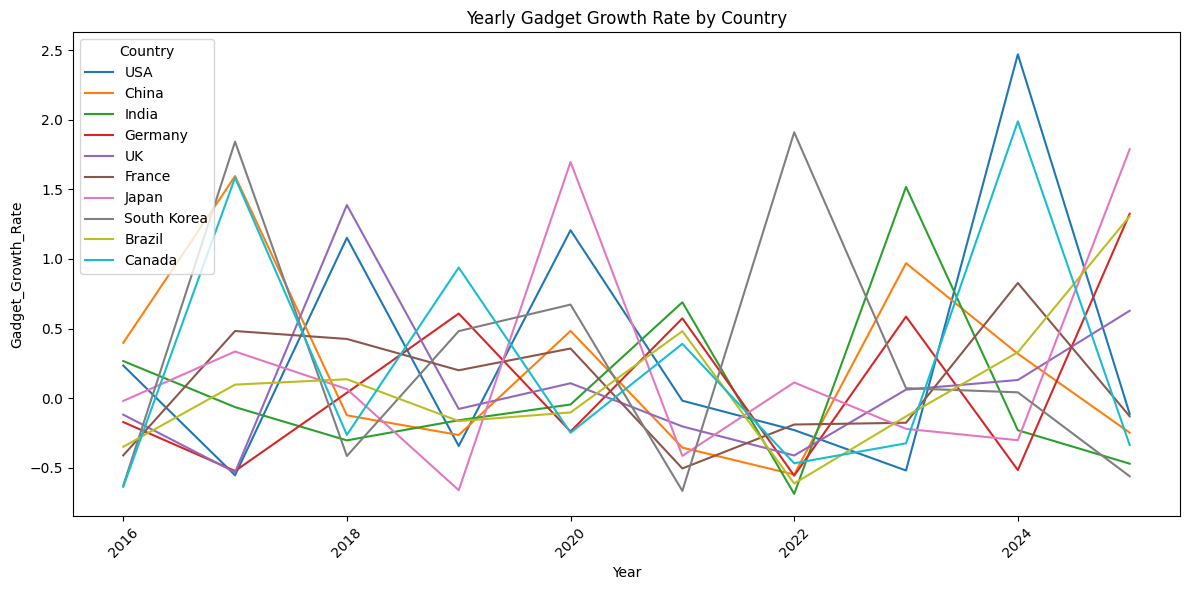

In [316]:
# Line Plot: Gadget_Growth_Rate over time by country
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Gadget_Growth_Rate', hue='Country')
plt.title('Yearly Gadget Growth Rate by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

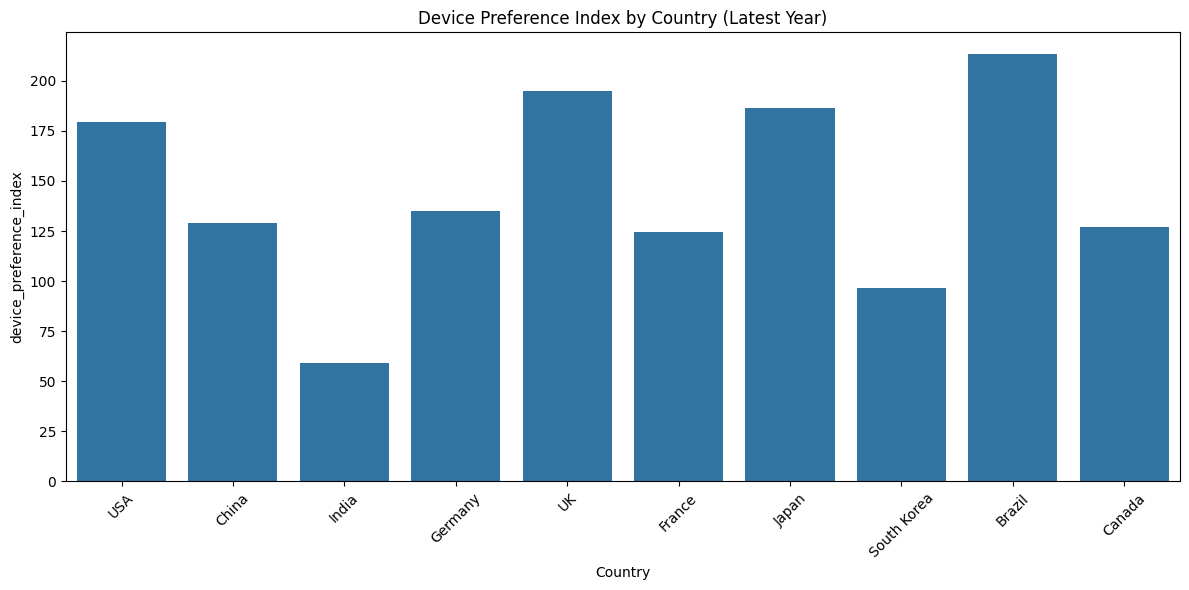

In [317]:
# Bar Chart: Device Preference Index by Country (Latest Year)
latest_year = df['Year'].max()
plt.figure(figsize=(12, 6))
sns.barplot(data=df[df['Year'] == latest_year], x='Country', y='device_preference_index')
plt.title('Device Preference Index by Country (Latest Year)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

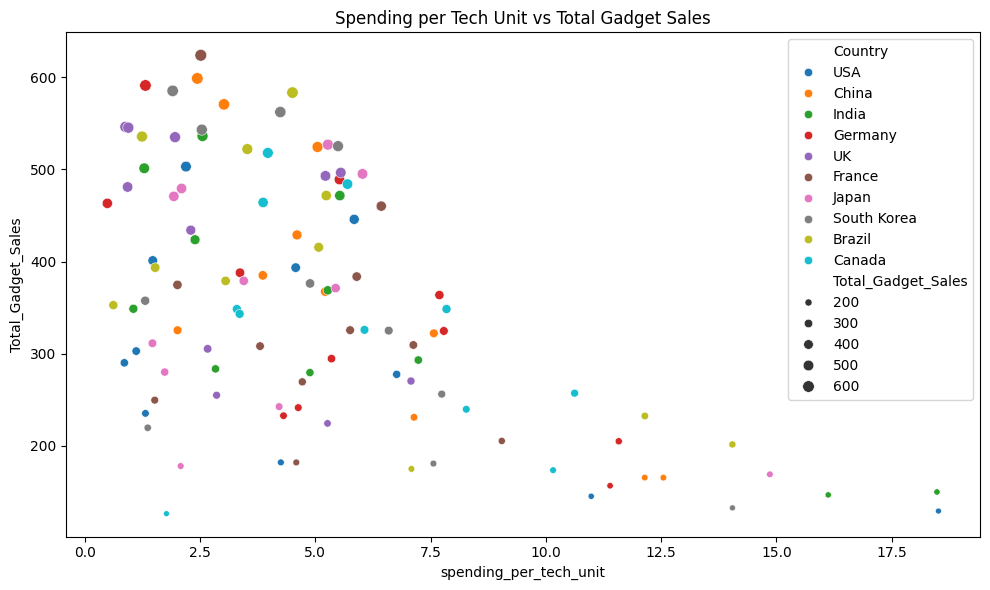

In [318]:
# Scatter Plot: Spending per Tech Unit vs Total Gadget Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='spending_per_tech_unit', y='Total_Gadget_Sales', hue='Country', size='Total_Gadget_Sales')
plt.title('Spending per Tech Unit vs Total Gadget Sales')
plt.tight_layout()
plt.show()

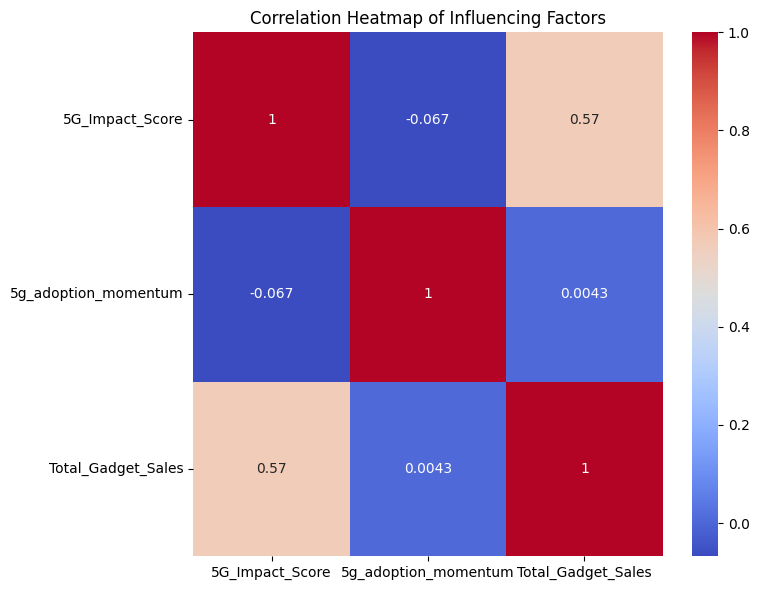

In [319]:
# Heatmap: Correlation Matrix for Influencing Features
corr_cols = ['5G_Impact_Score', '5g_adoption_momentum', 'Total_Gadget_Sales']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Influencing Factors')
plt.tight_layout()
plt.show()

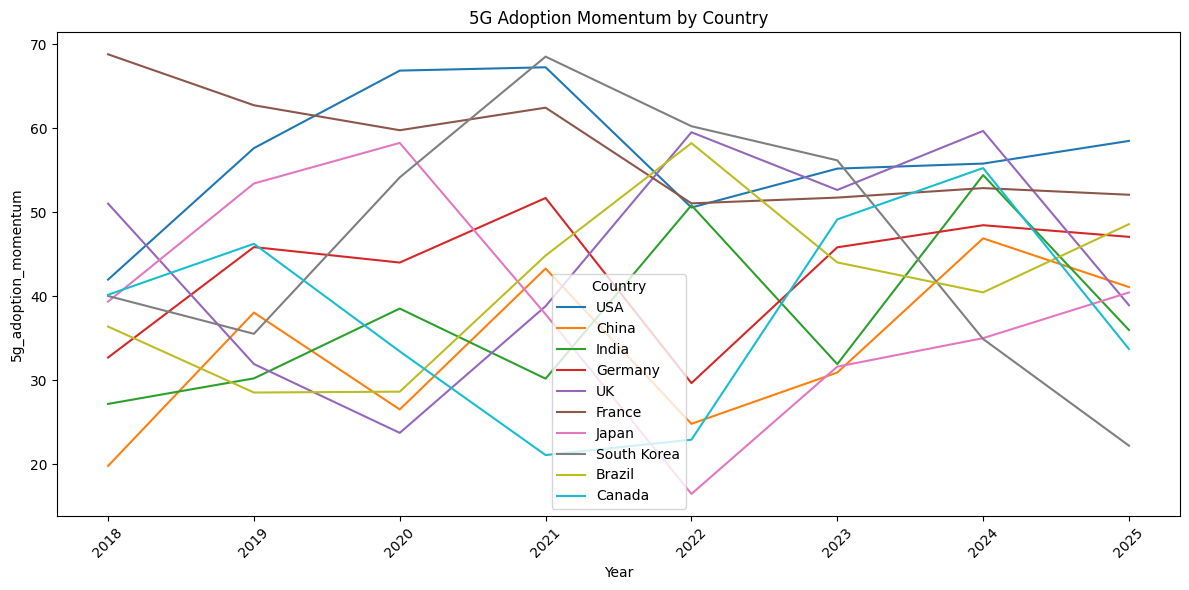

In [320]:
# Line Plot: 5G Adoption Momentum over Time by Country
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='5g_adoption_momentum', hue='Country')
plt.title('5G Adoption Momentum by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [321]:
# Radar Chart (Plotly) – Normalized Growth Scores by Country
radar_df = df[df['Year'] == latest_year][['Country', '5g_adoption_momentum']]
fig = px.line_polar(radar_df, r='5g_adoption_momentum', theta='Country', line_close=True, title='Normalized Growth Score by Country')
fig.show()

In [322]:
# Choropleth Map: Regional Adoption Score by Country
fig = px.choropleth(df[df['Year'] == latest_year],
                    locations='Country',
                    locationmode='country names',
                    color='Regional_Adoption_Score',
                    hover_name='Country',
                    title='Regional Adoption Score by Country',
                    color_continuous_scale='Plasma')
fig.show()

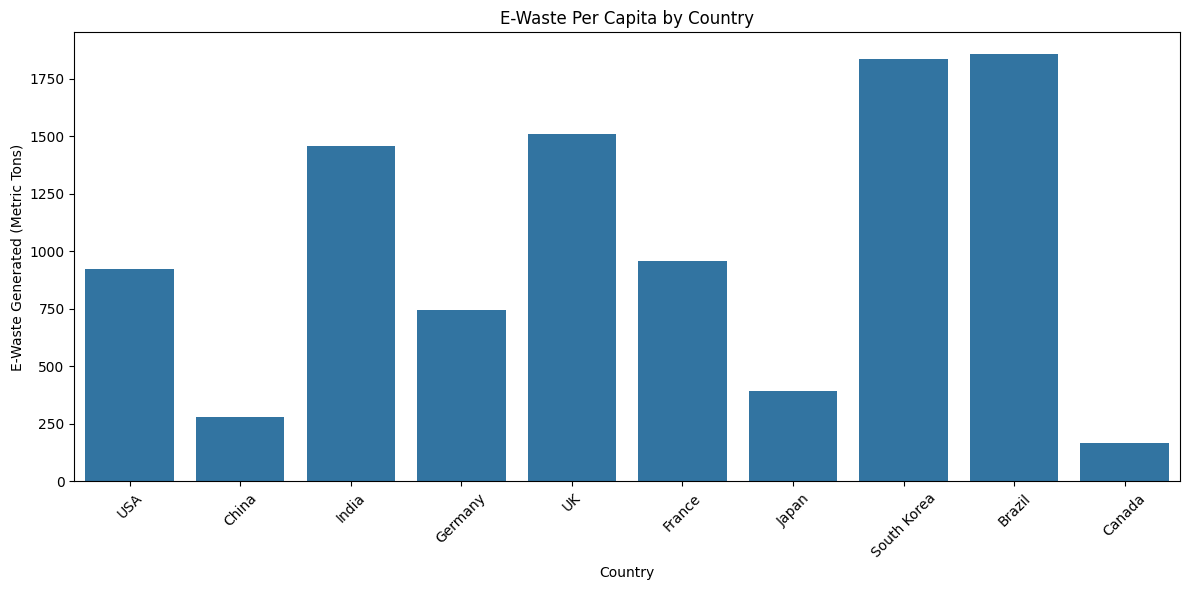

In [323]:
# Bar Plot: E-Waste Generated (Metric Tons) by Country
plt.figure(figsize=(12, 6))
sns.barplot(data=df[df['Year'] == latest_year], x='Country', y='E-Waste Generated (Metric Tons)') # Changed y to 'E-Waste Generated (Metric Tons)'
plt.title('E-Waste Per Capita by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

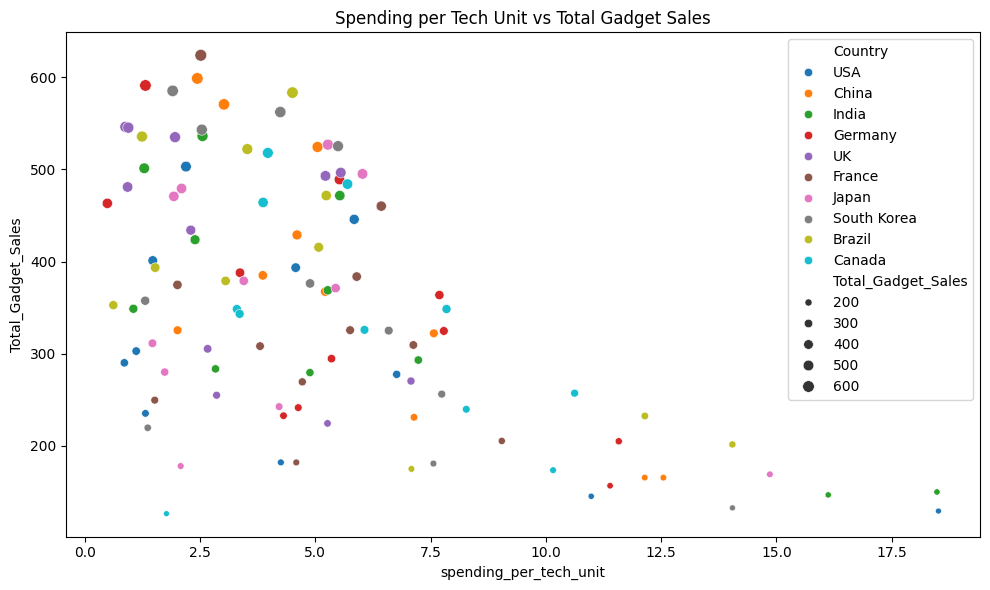

In [324]:
# Scatter Plot: Spending per Tech Unit vs Total Gadget Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='spending_per_tech_unit', y='Total_Gadget_Sales', hue='Country', size='Total_Gadget_Sales')
plt.title('Spending per Tech Unit vs Total Gadget Sales')
plt.tight_layout()
plt.show()

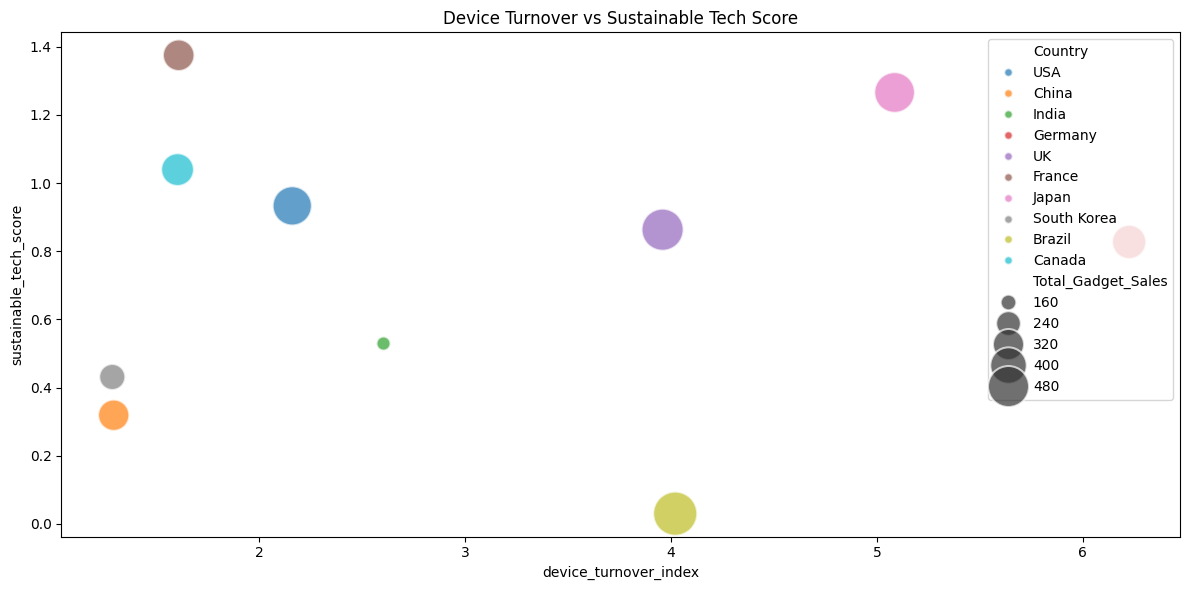

In [325]:
# Bubble Chart: Device Turnover vs Sustainability
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df[df['Year'] == latest_year],
                x='device_turnover_index',
                y='sustainable_tech_score',
                size='Total_Gadget_Sales',
                hue='Country',
                sizes=(100, 1000),
                alpha=0.7)
plt.title('Device Turnover vs Sustainable Tech Score')
plt.tight_layout()
plt.show()

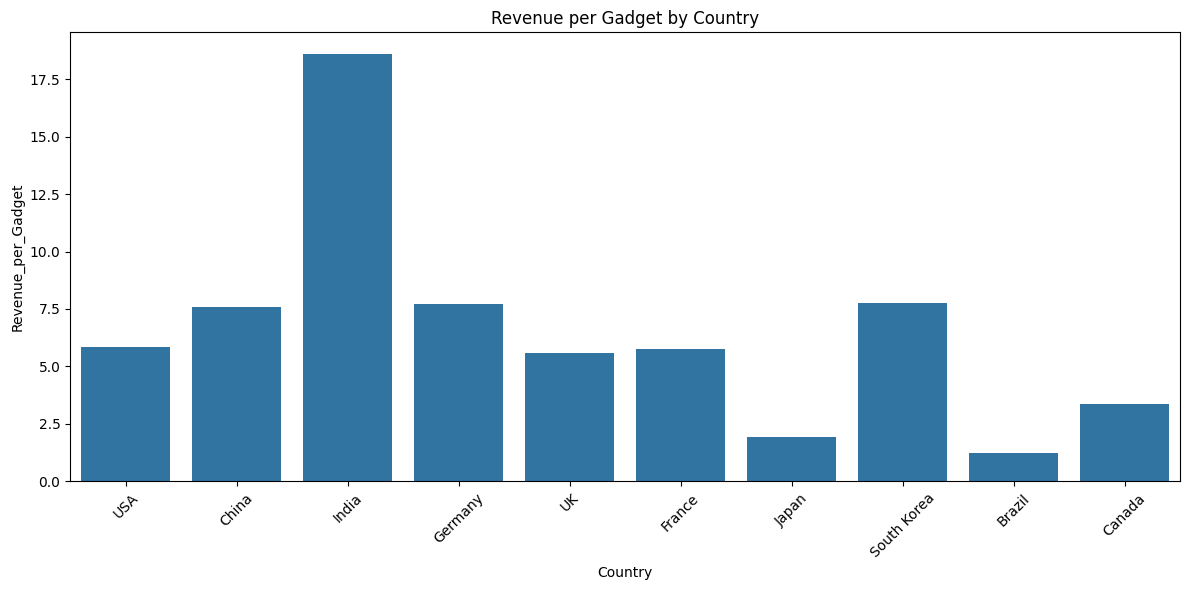

In [326]:
# Bar Chart: Revenue per Gadget by Country
plt.figure(figsize=(12, 6))
sns.barplot(data=df[df['Year'] == latest_year], x='Country', y='Revenue_per_Gadget')
plt.title('Revenue per Gadget by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


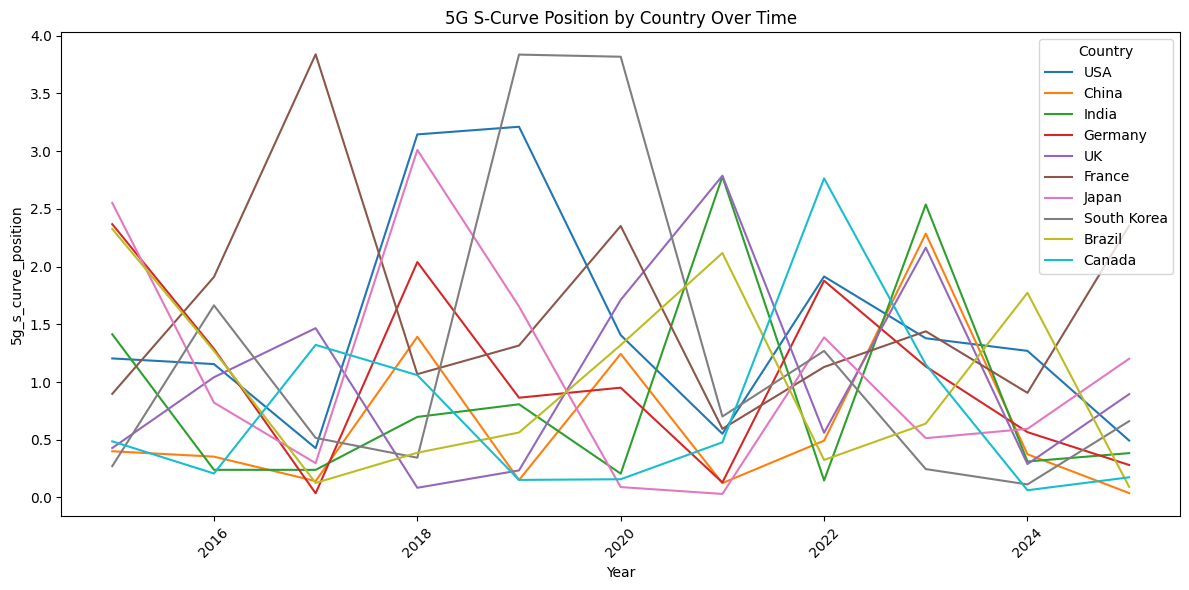

In [327]:
# Line Plot: 5G S-Curve Position Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='5g_s_curve_position', hue='Country')
plt.title('5G S-Curve Position by Country Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-328-2a54d1c69c1d>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




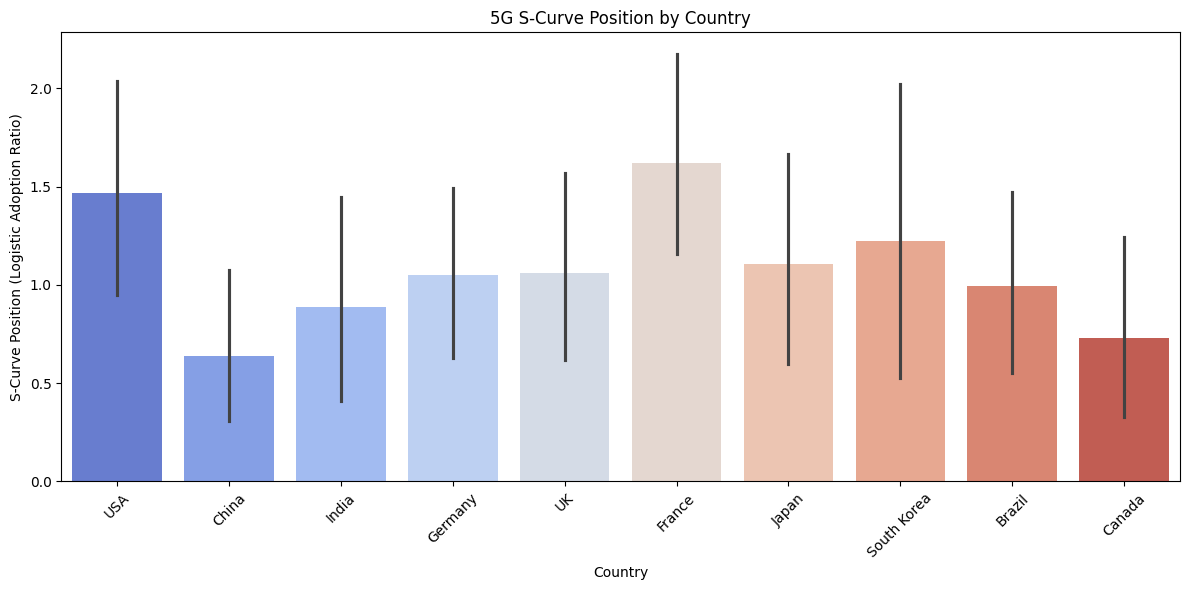

In [328]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Country', y='5g_s_curve_position', palette='coolwarm')
plt.title('5G S-Curve Position by Country')
plt.ylabel('S-Curve Position (Logistic Adoption Ratio)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-329-4ec2b47edee4>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




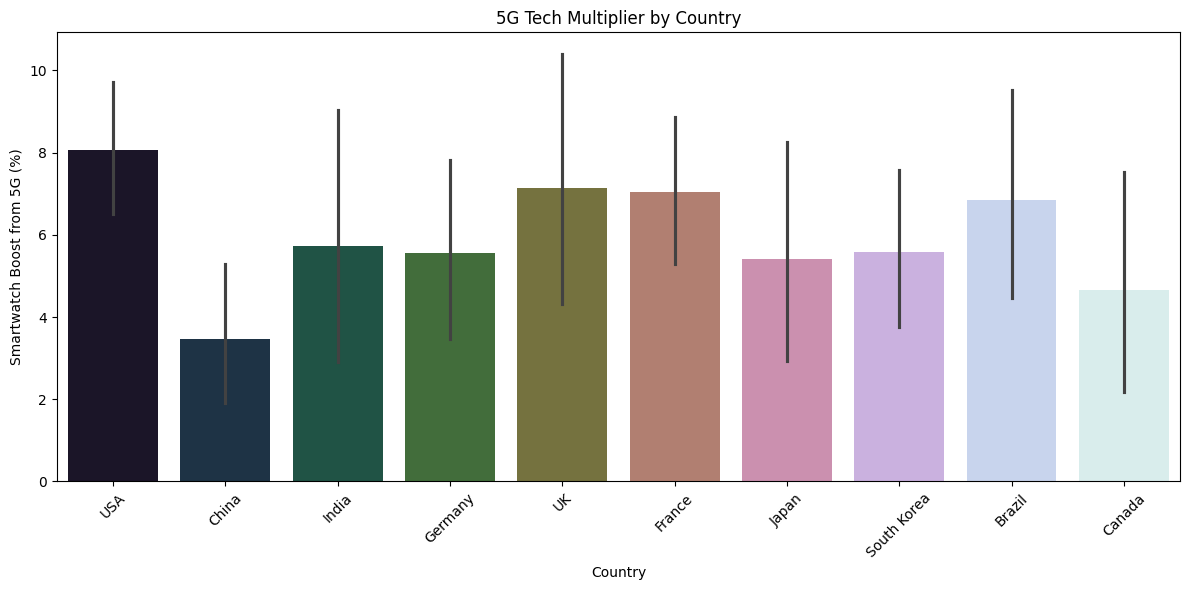

In [329]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Country', y='5g_tech_multiplier', palette='cubehelix')
plt.title('5G Tech Multiplier by Country')
plt.ylabel('Smartwatch Boost from 5G (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [330]:
# Save the DataFrame to a CSV file
# df.to_csv('tech_data_with_features.csv', index=False)

# print("✅ File saved as 'tech_data_with_features.csv'")


Use case 1

In [331]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# ------------------ Use Case 1: Market Research & Consumer Behavior ------------------
X1 = df[['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
         'Smartwatch Penetration (%)', 'device_preference_index', 'spending_per_tech_unit',
         '5g_readiness', 'Year']]
y1 = df['Total_Gadget_Sales']

# Feature selection using F-statistic (ANOVA F-test)
selector1 = SelectKBest(score_func=f_regression, k='all')
selector1.fit(X1, y1)

# Prepare DataFrame with feature scores
feature_scores1 = pd.DataFrame({
    'Feature': X1.columns,
    'F-Score': selector1.scores_,
    'P-Value': selector1.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Extract selected features
selected_features1 = X1.columns[selector1.get_support()]

# Display results
print("\n🎯 Use Case 1 - Market Research & Consumer Behavior Feature Importance")
print(feature_scores1.to_string(index=False))
print("\n✅ Selected Features:", list(selected_features1), "\n")



🎯 Use Case 1 - Market Research & Consumer Behavior Feature Importance
                    Feature      F-Score       P-Value
    device_preference_index 19189.201654 1.877622e-123
Smartphone Sales (Millions)  1340.291513  1.045667e-62
     spending_per_tech_unit    48.160034  3.043148e-10
Laptop Shipments (Millions)     8.738680  3.826085e-03
Gaming Console Adoption (%)     6.512979  1.210734e-02
 Smartwatch Penetration (%)     1.707127  1.941341e-01
                       Year     0.850496  3.584677e-01
               5g_readiness     0.255272  6.144167e-01

✅ Selected Features: ['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)', 'device_preference_index', 'spending_per_tech_unit', '5g_readiness', 'Year'] 



In [332]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Manually select top 5 features from the ranked feature_scores1 DataFrame
top_5_features = feature_scores1['Feature'].head(5).tolist()
X1_top5 = df[top_5_features]

# Fit K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X1_top5)

# Evaluate clustering
sil_score = silhouette_score(X1_top5, kmeans_labels)
inertia = kmeans.inertia_

print("🔍 K-Means Clustering Evaluation (Use Case 1):")
print("Silhouette Score:", sil_score)
print("Inertia:", inertia)

🔍 K-Means Clustering Evaluation (Use Case 1):
Silhouette Score: 0.5004829467182631
Inertia: 365670.5546137014


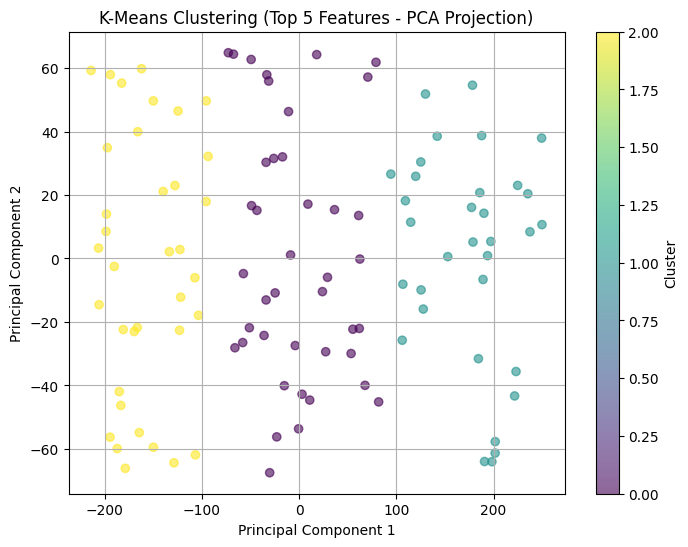

In [333]:
# Optional: Visualize clusters using PCA
pca = PCA(n_components=2)
X1_pca = pca.fit_transform(X1_top5)

plt.figure(figsize=(8, 6))
plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clustering (Top 5 Features - PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


scaling

In [334]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1[top_5_features])  # Use your top 5 features


Elbow Method or Silhouette Analysis

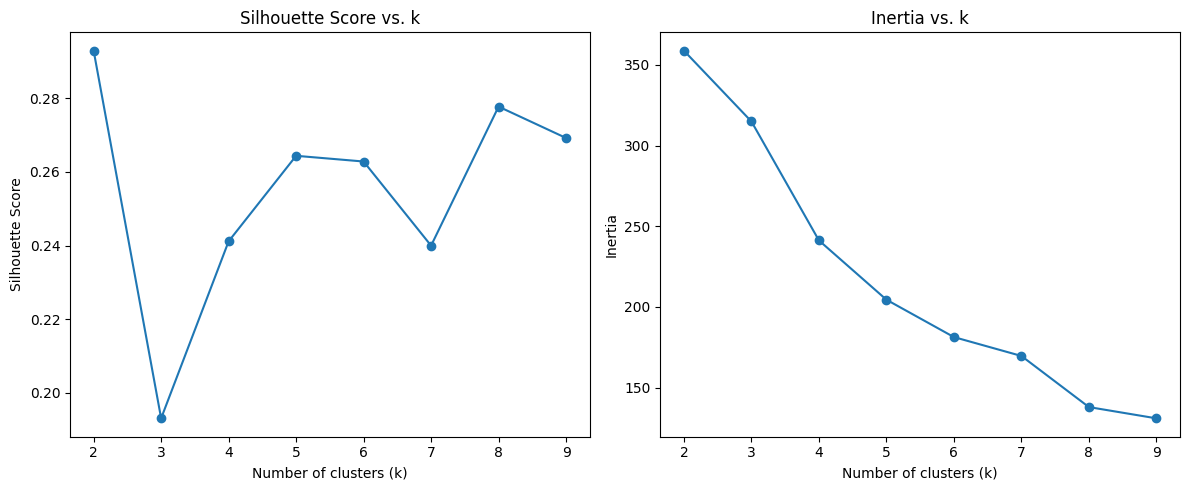

In [335]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
inertias = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X1_scaled)
    sil_scores.append(silhouette_score(X1_scaled, labels))
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Score vs. k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), inertias, marker='o')
plt.title('Inertia vs. k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()


PCA or t-SNE for Dimensionality Reduction

In [336]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X1_reduced = pca.fit_transform(X1_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X1_reduced)


In [337]:
sil_score = silhouette_score(X1_pca, kmeans_labels)
inertia = kmeans.inertia_
print(sil_score)
print(inertia)

0.5092650270162419
138.65454772781388


Use case 2

In [338]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# ------------------ Use Case 2: Forecasting Future Tech Trends ------------------

X2 = df[['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)', '5g_readiness',
         'Smartwatch Penetration (%)', 'spending_per_tech_unit', 'Year', '5G Penetration Rate (%)', 'Average Consumer Spending on Gadgets ($)',
         'device_preference_index', '5g_s_curve_position', '5g_tech_multiplier']]
y2 = df['5G_Impact_Score']  # Replace with your target column for forecasting

# Feature selection
selector2 = SelectKBest(score_func=f_regression, k='all')
selector2.fit(X2, y2)

# Prepare DataFrame with scores
feature_scores2 = pd.DataFrame({
    'Feature': X2.columns,
    'F-Score': selector2.scores_,
    'P-Value': selector2.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Selected features
selected_features2 = X2.columns[selector2.get_support()]

# Display results
print("\n📊 Use Case 2 - Forecasting Future Tech Trends: Feature Importance")
print(feature_scores2.to_string(index=False))
print("\n✅ Selected Features:", list(selected_features2), "\n")



📊 Use Case 2 - Forecasting Future Tech Trends: Feature Importance
                                 Feature    F-Score      P-Value
                            5g_readiness 109.497837 4.090264e-18
                 5G Penetration Rate (%) 108.413163 5.370797e-18
                     5g_s_curve_position  94.707544 1.900990e-16
             Smartphone Sales (Millions)  61.861677 2.996727e-12
                 device_preference_index  55.065214 2.817765e-11
                      5g_tech_multiplier  22.880463 5.490074e-06
                  spending_per_tech_unit  10.199029 1.841577e-03
             Gaming Console Adoption (%)   2.746955 1.003420e-01
                                    Year   2.509652 1.160748e-01
              Smartwatch Penetration (%)   1.680855 1.975743e-01
Average Consumer Spending on Gadgets ($)   0.841477 3.610187e-01
             Laptop Shipments (Millions)   0.193626 6.607949e-01

✅ Selected Features: ['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Ga

In [339]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- Step 1: Top 5 Features ---------------- #
# Already selected based on F-score and P-value
top_features2 = feature_scores2.head(6)['Feature'].tolist()
X2_top = df[top_features2]
y2 = df['5G_Impact_Score']

# ---------------- Step 2: Train-Test Split ---------------- #
X_train, X_test, y_train, y_test = train_test_split(X2_top, y2, test_size=0.2, random_state=42)

# ---------------- Step 3: Train XGBoost Regressor ---------------- #
model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# ---------------- Step 4: Make Predictions ---------------- #
y_pred = model.predict(X_test)

# ---------------- Step 5: Evaluate Model ---------------- #
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📉 Mean Squared Error:", mse)
print("🔢 R² Score:", r2)


📉 Mean Squared Error: 2379471.4995747935
🔢 R² Score: 0.9482541676102935


<Figure size 800x600 with 0 Axes>

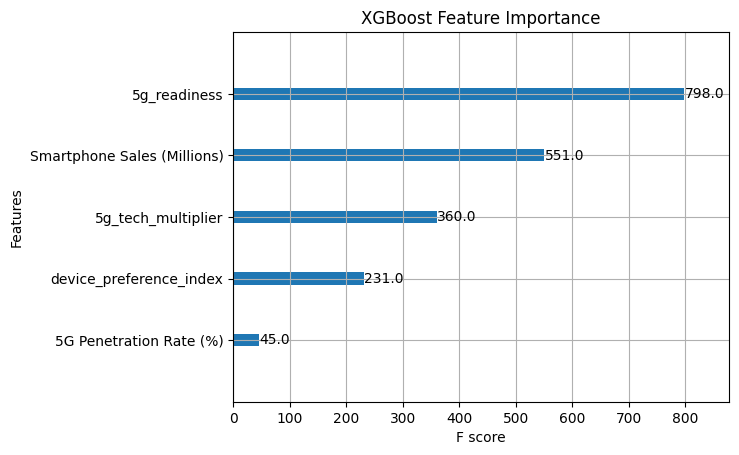

In [340]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importance
plt.figure(figsize=(8, 6))
xgb.plot_importance(model)
plt.title('XGBoost Feature Importance')
plt.show()


In [341]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
y2_pred = model.predict(X2_top)

# Evaluate
mse = mean_squared_error(y2, y2_pred)
r2 = r2_score(y2, y2_pred)

print(f"📈 Mean Squared Error: {mse}")
print(f"🔢 R² Score: {r2}")


📈 Mean Squared Error: 475894.30231898185
🔢 R² Score: 0.9937305455387172


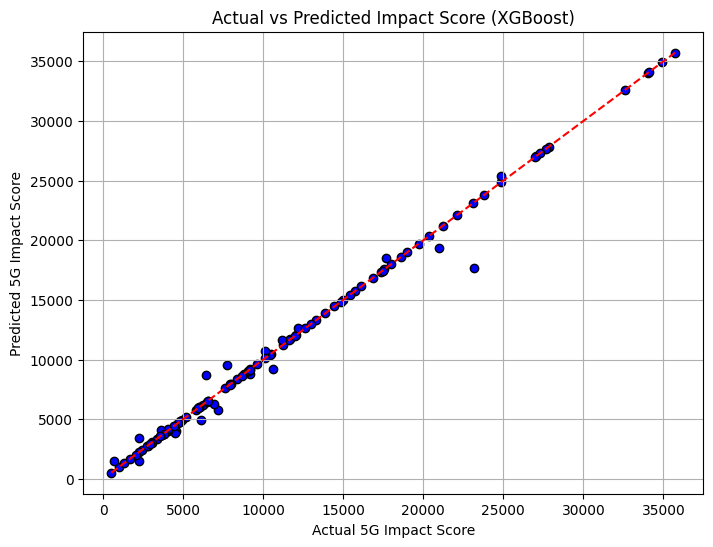

In [342]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y2, y2_pred, color='blue', edgecolor='k')
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'r--')  # Diagonal line
plt.xlabel('Actual 5G Impact Score')
plt.ylabel('Predicted 5G Impact Score')
plt.title('Actual vs Predicted Impact Score (XGBoost)')
plt.grid(True)
plt.show()


In [343]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X2_top, y2, scoring='r2', cv=5)
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())


Cross-validated R² scores: [0.96260822 0.98212932 0.88541582 0.97890473 0.97858598]
Average R²: 0.9575288139895362


In [344]:
# Ensure the same features and order as used in training
future_data = pd.DataFrame([{
    '5g_readiness': 0.88,  # Include this if it was in your top features
    '5G Penetration Rate (%)': 75,
    '5g_s_curve_position': 0.9,
    'Smartphone Sales (Millions)': 1400,
    'device_preference_index': 0.85,
    '5g_tech_multiplier': 1.5
}])[X2_top.columns]  # ensures correct order

# Make prediction
future_prediction = model.predict(future_data)
print("🔮 Forecasted 5G Impact Score:", future_prediction[0])


🔮 Forecasted 5G Impact Score: 10336.262


In [345]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define the model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Setup the GridSearch
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           verbose=1,
                           n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X2_top, y2)

# Best parameters and score
print("✅ Best Parameters:", grid_search.best_params_)
print("📈 Best R² Score from GridSearchCV:", grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}
📈 Best R² Score from GridSearchCV: 0.9781507406567048


In [346]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Final model with best parameters from GridSearchCV
final_model = XGBRegressor(
    colsample_bytree=1,
    learning_rate=0.1,
    max_depth=3,
    n_estimators=150,
    subsample=0.8,
    random_state=42
)

# Train the final model on full training data
final_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [347]:
# Training set performance
train_preds = final_model.predict(X_train)
train_mse = mean_squared_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

# Test set performance
test_preds = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print("🏋️ Train MSE:", train_mse)
print("🏋️‍♂️ Train R²:", train_r2)

print("🧪 Test MSE:", test_mse)
print("🧪 Test R²:", test_r2)


🏋️ Train MSE: 7904.293657179547
🏋️‍♂️ Train R²: 0.9999031049646667
🧪 Test MSE: 1684654.049661085
🧪 Test R²: 0.9633642066719519


In [348]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(final_model, X2_top, y2, cv=5, scoring='r2')
print("🔁 Cross-validated R² scores:", cv_scores)
print("📈 Average R²:", cv_scores.mean())


🔁 Cross-validated R² scores: [0.98716432 0.98165511 0.94433741 0.9843127  0.99328416]
📈 Average R²: 0.9781507406567048


In [349]:
# Ensure the 'Year' column is in datetime format (if applicable)
df_arima = df[['Year', '5G_Impact_Score']].copy()
df_arima = df_arima.sort_values('Year')  # Sorting by time
df_arima.set_index('Year', inplace=True)


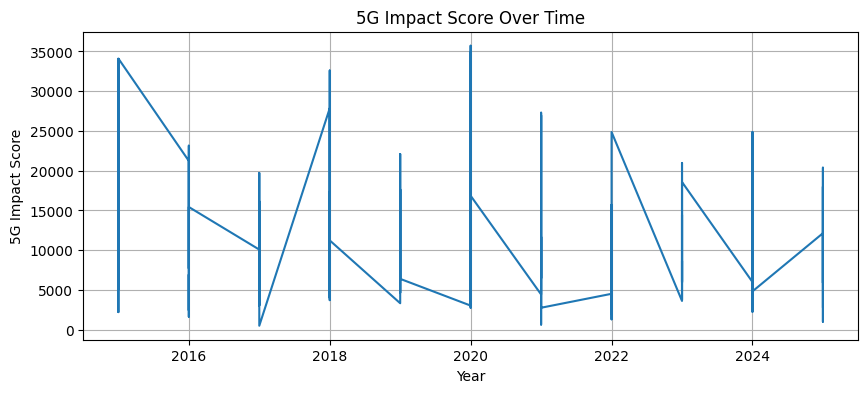

In [350]:
import matplotlib.pyplot as plt

df_arima['5G_Impact_Score'].plot(figsize=(10, 4), title='5G Impact Score Over Time')
plt.xlabel('Year')
plt.ylabel('5G Impact Score')
plt.grid(True)
plt.show()


In [351]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_arima['5G_Impact_Score'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


ADF Statistic: -9.709052837924089
p-value: 1.023193845958444e-16


In [352]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_arima, order=(1, 1, 1))  # (p, d, q)
model_fit = model_arima.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:        5G_Impact_Score   No. Observations:                  110
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1147.261
Date:                Wed, 09 Apr 2025   AIC                           2300.521
Time:                        11:57:46   BIC                           2308.595
Sample:                             0   HQIC                          2303.796
                                - 110                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0646      0.112      0.577      0.564      -0.155       0.284
ma.L1         -0.9758      0.056    -17.355      0.000      -1.086      -0.866
sigma2      9.341e+07   7.66e-11   1.22e+18      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



In [353]:
forecast = model_fit.forecast(steps=5)
print("📈 Forecast for next 5 years:\n", forecast)


📈 Forecast for next 5 years:
 110     9941.560946
111    10396.407168
112    10425.768236
113    10427.663541
114    10427.785886
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



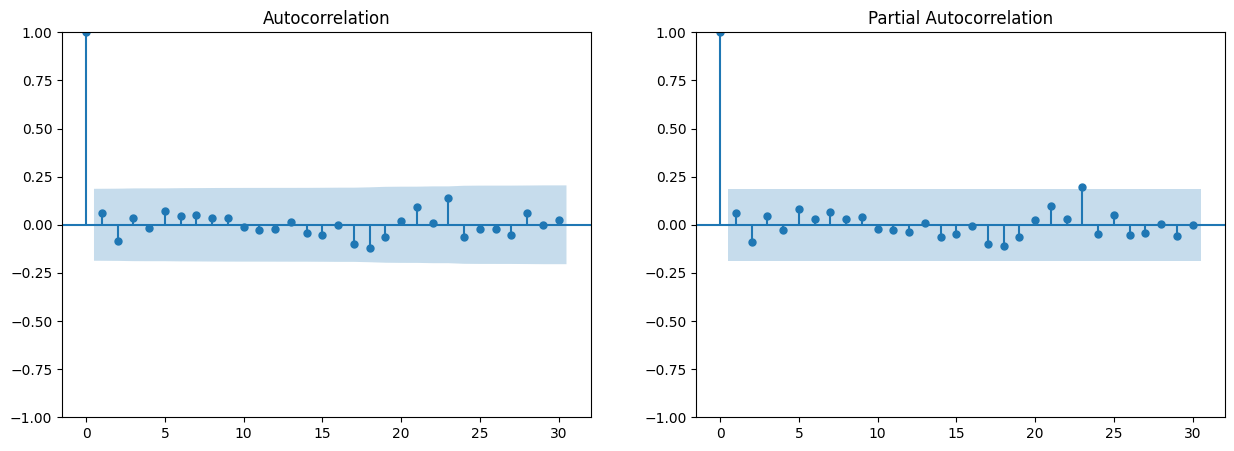

In [354]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
ts = df_arima['5G_Impact_Score']
# Assuming your time series is called `ts`
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(ts, lags=30, ax=axes[0])
plot_pacf(ts, lags=30, ax=axes[1])
plt.show()


In [355]:
from statsmodels.tsa.arima.model import ARIMA

# Example with p=1, d=0, q=1 (replace with actual values from plots)
model = ARIMA(ts, order=(1, 0, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
print(forecast)


                               SARIMAX Results                                
Dep. Variable:        5G_Impact_Score   No. Observations:                  110
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1152.918
Date:                Wed, 09 Apr 2025   AIC                           2313.836
Time:                        11:57:46   BIC                           2324.638
Sample:                             0   HQIC                          2318.217
                                - 110                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.142e+04    847.013     13.484      0.000    9760.596    1.31e+04
ar.L1         -0.8725      0.129     -6.739      0.000      -1.126      -0.619
ma.L1          0.9468      0.100      9.424      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.11/dist-packages/st

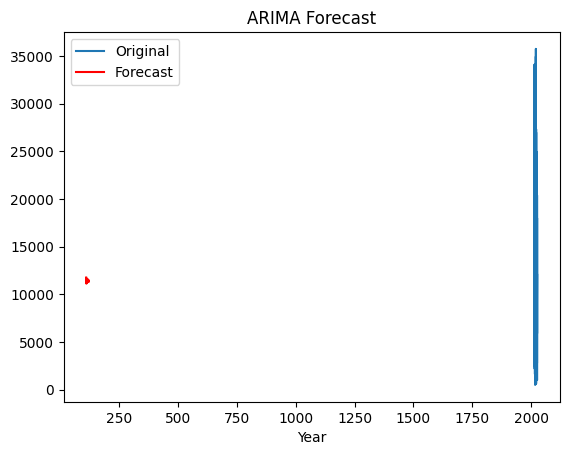

In [356]:
ts.plot(label='Original')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()


In [357]:
print(ts.index)
print(forecast.index)


Index([2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015,
       ...
       2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025],
      dtype='int64', name='Year', length=110)
RangeIndex(start=110, stop=122, step=1)


Use Case 3

In [358]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# ------------------ Use Case 3: Estimating Sustainable Tech Score ------------------

X3 = df[['Revenue_per_Gadget', '5G_Impact_Score', '5g_readiness',
         'spending_per_tech_unit', '5g_s_curve_position', '5g_tech_multiplier',
         'ewaste_intensity', 'device_turnover_index', 'Gadget_Growth_Rate',
         'E-Waste Generated (Metric Tons)',  '5G Penetration Rate (%)', 'Smartwatch Penetration (%)',
         'Country_Num']]
y3 = df['sustainable_tech_score']  # Target variable
X3 = X3.fillna(0)# Feature selection
selector3 = SelectKBest(score_func=f_regression, k='all')
selector3.fit(X3, y3)

# Prepare DataFrame with scores
feature_scores3 = pd.DataFrame({
    'Feature': X3.columns,
    'F-Score': selector3.scores_,
    'P-Value': selector3.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Selected features
selected_features3 = X3.columns[selector3.get_support()]

# Display results
print("\n📊 Use Case 3 - Estimating Sustainable Tech Score: Feature Importance")
print(feature_scores3.to_string(index=False))
print("\n✅ Selected Features:", list(selected_features3), "\n")



📊 Use Case 3 - Estimating Sustainable Tech Score: Feature Importance
                        Feature   F-Score      P-Value
E-Waste Generated (Metric Tons) 35.573532 3.153521e-08
                   5g_readiness 12.784816 5.241622e-04
        5G Penetration Rate (%) 12.608111 5.703677e-04
               ewaste_intensity 12.076762 7.361864e-04
            5g_s_curve_position  8.215543 4.993720e-03
                5G_Impact_Score  6.909091 9.825212e-03
         spending_per_tech_unit  5.882222 1.695249e-02
             Revenue_per_Gadget  5.861194 1.714536e-02
          device_turnover_index  2.506620 1.162929e-01
             5g_tech_multiplier  2.263027 1.354137e-01
                    Country_Num  0.857494 3.565055e-01
     Smartwatch Penetration (%)  0.773207 3.811790e-01
             Gadget_Growth_Rate  0.412956 5.218349e-01

✅ Selected Features: ['Revenue_per_Gadget', '5G_Impact_Score', '5g_readiness', 'spending_per_tech_unit', '5g_s_curve_position', '5g_tech_multiplier', 'ewaste_i

In [359]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Ensure missing values are handled
df.fillna(0, inplace=True)

# ---------------- Step 1: Top 4 Features ---------------- #
# Already selected based on F-score and P-value
top_features3 = feature_scores3.head(4)['Feature'].tolist()
X3_top = df[top_features3]
y3 = df['sustainable_tech_score']

# ---------------- Step 2: Train-Test Split ---------------- #
X_train, X_test, y_train, y_test = train_test_split(X3_top, y3, test_size=0.2, random_state=42)

# ---------------- Step 3: Train XGBoost Regressor ---------------- #
model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# ---------------- Step 4: Make Predictions ---------------- #
y_pred = model.predict(X_test)

# ---------------- Step 5: Evaluate Model ---------------- #
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📉 Mean Squared Error (Use Case 3):", mse)
print("🔢 R² Score (Use Case 3):", r2)


📉 Mean Squared Error (Use Case 3): 0.9459026431364103
🔢 R² Score (Use Case 3): 0.8963023042119409


In [360]:
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- Predict on Train Data ---------------- #
y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# ---------------- Predict on Test Data ---------------- #
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# ---------------- Print Results ---------------- #
print("📘 Train Data:")
print("  🔹 Mean Squared Error:", train_mse)
print("  🔹 R² Score:", train_r2)

print("\n📙 Test Data:")
print("  🔸 Mean Squared Error:", test_mse)
print("  🔸 R² Score:", test_r2)


📘 Train Data:
  🔹 Mean Squared Error: 1.2248899032898126e-06
  🔹 R² Score: 0.9999993645020538

📙 Test Data:
  🔸 Mean Squared Error: 0.9459026431364103
  🔸 R² Score: 0.8963023042119409


<Figure size 1000x1200 with 0 Axes>

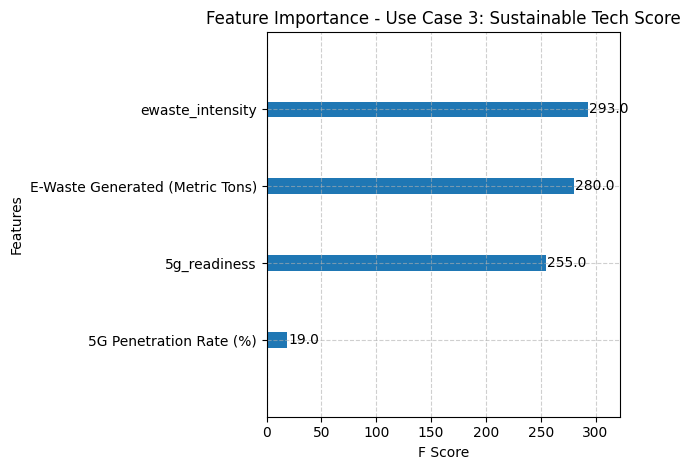

In [361]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance
plt.figure(figsize=(10, 12))
plot_importance(model, importance_type='weight', xlabel='F Score')
plt.title('Feature Importance - Use Case 3: Sustainable Tech Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


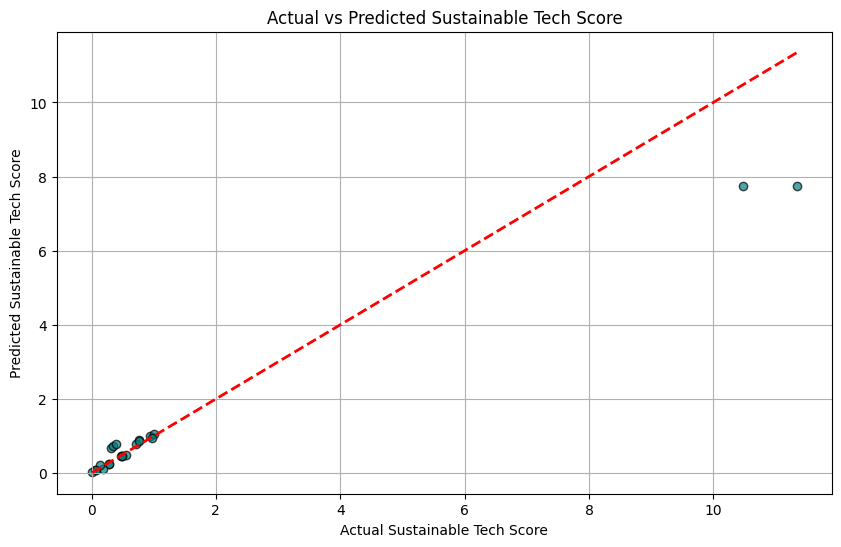

In [362]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='teal', edgecolors='black', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sustainable Tech Score")
plt.ylabel("Predicted Sustainable Tech Score")
plt.title("Actual vs Predicted Sustainable Tech Score")
plt.grid(True)
plt.show()


In [363]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X2_top, y2, cv=5, scoring='r2')
print("Cross-Validation R² Scores:", scores)
print("Average R² Score:", scores.mean())


Cross-Validation R² Scores: [0.96260822 0.98212932 0.88541582 0.97890473 0.97858598]
Average R² Score: 0.9575288139895362


In [364]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
                           param_grid=param_grid, cv=3, scoring='neg_mean_squared_error')

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

# Train model with best parameters
best_model = grid_search.best_estimator_

# Make predictions on test data
best_y_pred = best_model.predict(X_test)

# Evaluate performance with best model
best_test_mse = mean_squared_error(y_test, best_y_pred)
best_test_r2 = r2_score(y_test, best_y_pred)

print("🔧 Optimized Test Mean Squared Error:", best_test_mse)
print("🔧 Optimized Test R² Score:", best_test_r2)


Best Parameters from GridSearchCV: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
🔧 Optimized Test Mean Squared Error: 0.936698930911471
🔧 Optimized Test R² Score: 0.8973112915082


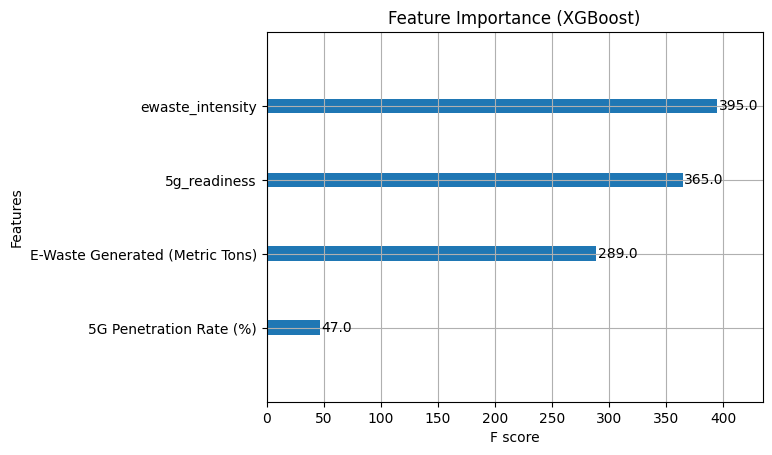

In [365]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Plot feature importance
xgb.plot_importance(best_model)
plt.title("Feature Importance (XGBoost)")
plt.show()


In [366]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on the model
cv_scores = cross_val_score(best_model, X3_top, y3, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation scores
print("Cross-Validation Scores:", -cv_scores)
print("Average Cross-Validation Score:", -cv_scores.mean())


Cross-Validation Scores: [1.23523178 0.0225748  0.28928168 0.93854807 0.24366301]
Average Cross-Validation Score: 0.5458598693161381


In [367]:
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- Step 1: Train the Optimized Model ---------------- #
best_model.fit(X_train, y_train)

# ---------------- Step 2: Make Predictions ---------------- #
# Predict on the training set
y_train_pred = best_model.predict(X_train)

# Predict on the test set
y_test_pred = best_model.predict(X_test)

# ---------------- Step 3: Evaluate the Model ---------------- #

# Calculate R² Score and MSE for Train Set
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)

# Calculate R² Score and MSE for Test Set
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# ---------------- Step 4: Display the Results ---------------- #
print("📈 Train R² Score: ", train_r2)
print("📉 Train Mean Squared Error (MSE): ", train_mse)

print("\n📈 Test R² Score: ", test_r2)
print("📉 Test Mean Squared Error (MSE): ", test_mse)


📈 Train R² Score:  0.9999310987738657
📉 Train Mean Squared Error (MSE):  0.00013280360185799416

📈 Test R² Score:  0.8973112915082
📉 Test Mean Squared Error (MSE):  0.936698930911471


In [368]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# Use the same dataset (make sure it's clean)
df.fillna(0, inplace=True)

# Selecting features and target
X = df[['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
        '5g_readiness', 'Smartwatch Penetration (%)', 'spending_per_tech_unit', 'Year',
        '5G Penetration Rate (%)', 'Average Consumer Spending on Gadgets ($)', 'device_preference_index',
        '5g_s_curve_position', '5g_tech_multiplier', 'E-Waste Generated (Metric Tons)',
        'ewaste_intensity', 'Country_Num']]
y = df['sustainable_tech_score']  # Target variable

# Feature selection using f_regression (ANOVA F-statistic for regression)
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Get F-scores and p-values
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Display feature importance scores
print("\n📊 Feature Importance - F-Score and P-Value:")
print(feature_scores.to_string(index=False))




📊 Feature Importance - F-Score and P-Value:
                                 Feature   F-Score      P-Value
         E-Waste Generated (Metric Tons) 35.573532 3.153521e-08
                            5g_readiness 12.784816 5.241622e-04
                 5G Penetration Rate (%) 12.608111 5.703677e-04
                        ewaste_intensity 12.076762 7.361864e-04
Average Consumer Spending on Gadgets ($) 11.150677 1.153604e-03
                     5g_s_curve_position  8.215543 4.993720e-03
                  spending_per_tech_unit  5.882222 1.695249e-02
                      5g_tech_multiplier  2.263027 1.354137e-01
             Gaming Console Adoption (%)  1.291411 2.583034e-01
                             Country_Num  0.857494 3.565055e-01
              Smartwatch Penetration (%)  0.773207 3.811790e-01
             Laptop Shipments (Millions)  0.622683 4.317810e-01
                                    Year  0.112056 7.384646e-01
             Smartphone Sales (Millions)  0.049778 8.238708

In [369]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Select the top 5 features based on F-Score
top_5_features = feature_scores.head(4)['Feature'].tolist()

# Select only the top 5 features
X_top_5 = df[top_5_features]
y = df['sustainable_tech_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_top_5, y, test_size=0.2, random_state=42)

# Create RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate the model
train_r2_rf = r2_score(y_train, y_train_pred_rf)
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

# Display results
print("\nRandom Forest - Train R² Score: ", train_r2_rf)
print("Random Forest - Train Mean Squared Error (MSE): ", train_mse_rf)

print("\nRandom Forest - Test R² Score: ", test_r2_rf)
print("Random Forest - Test Mean Squared Error (MSE): ", test_mse_rf)



Random Forest - Train R² Score:  0.9585718641674437
Random Forest - Train Mean Squared Error (MSE):  0.07985062045331581

Random Forest - Test R² Score:  0.8340465192122918
Random Forest - Test Mean Squared Error (MSE):  1.5137832612559996


In [370]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV with Random Forest
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
best_params = grid_search.best_params_

# Display the best parameters
print("\nBest Parameters from GridSearchCV:", best_params)

# Use the best model found
best_rf_model = grid_search.best_estimator_

# Evaluate the optimized model
y_train_pred_best = best_rf_model.predict(X_train)
y_test_pred_best = best_rf_model.predict(X_test)

# Evaluate the optimized model
train_r2_best = r2_score(y_train, y_train_pred_best)
train_mse_best = mean_squared_error(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
test_mse_best = mean_squared_error(y_test, y_test_pred_best)

# Display the results
print("\nOptimized Random Forest - Train R² Score: ", train_r2_best)
print("Optimized Random Forest - Train Mean Squared Error (MSE): ", train_mse_best)

print("\nOptimized Random Forest - Test R² Score: ", test_r2_best)
print("Optimized Random Forest - Test Mean Squared Error (MSE): ", test_mse_best)


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters from GridSearchCV: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Optimized Random Forest - Train R² Score:  0.9594728068508805
Optimized Random Forest - Train Mean Squared Error (MSE):  0.07811409934707819

Optimized Random Forest - Test R² Score:  0.8351960165899126
Optimized Random Forest - Test Mean Squared Error (MSE):  1.5032978536535757


In [371]:
from sklearn.model_selection import cross_val_score

# Evaluate the model using cross-validation
cv_scores = cross_val_score(rf_model, X_top_5, y, cv=5, scoring='neg_mean_squared_error')

# Display the cross-validation results
print("\nCross-Validation Scores (Negative MSE):", cv_scores)
print("Average Cross-Validation Score (Negative MSE):", cv_scores.mean())



Cross-Validation Scores (Negative MSE): [-0.98054644 -0.097912   -0.35247502 -1.58189351 -0.8172374 ]
Average Cross-Validation Score (Negative MSE): -0.7660128756085147


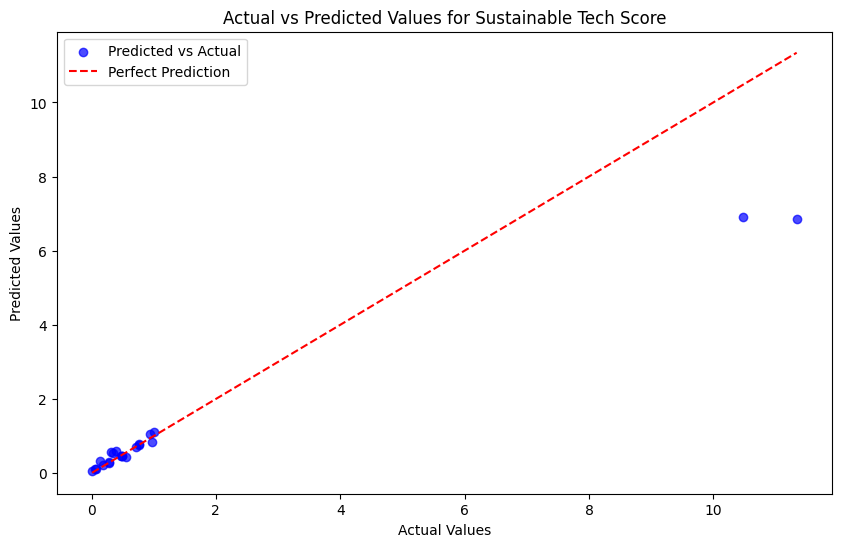

In [372]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted values for the test set
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_test, y_test_pred_best, color='blue', label='Predicted vs Actual', alpha=0.7)

# Plot line of perfect prediction (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values for Sustainable Tech Score')
plt.legend()

# Show plot
plt.show()


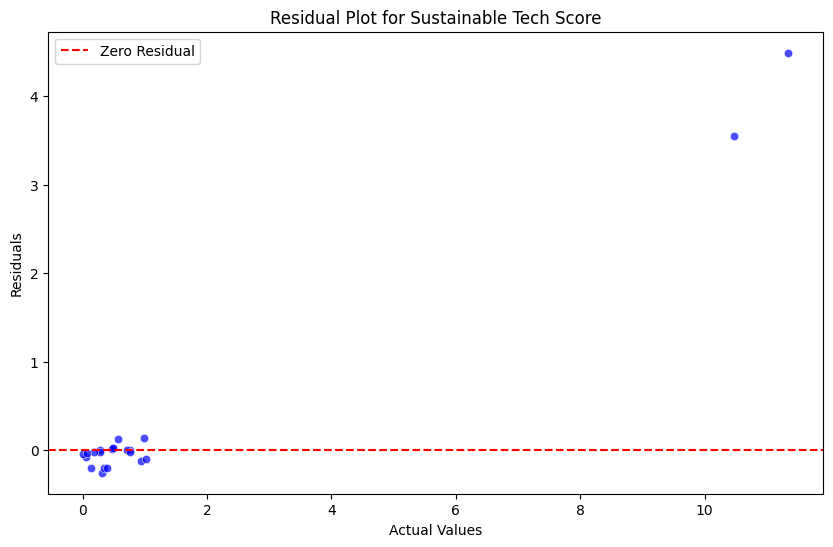

In [373]:
# Residual Plot
plt.figure(figsize=(10, 6))

# Residuals are the difference between actual and predicted values
residuals = y_test - y_test_pred_best

# Plot residuals
sns.scatterplot(x=y_test, y=residuals, color='blue', alpha=0.7)

# Plot horizontal line at 0 (no error)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')

# Labels and title
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Sustainable Tech Score')
plt.legend()

# Show plot
plt.show()


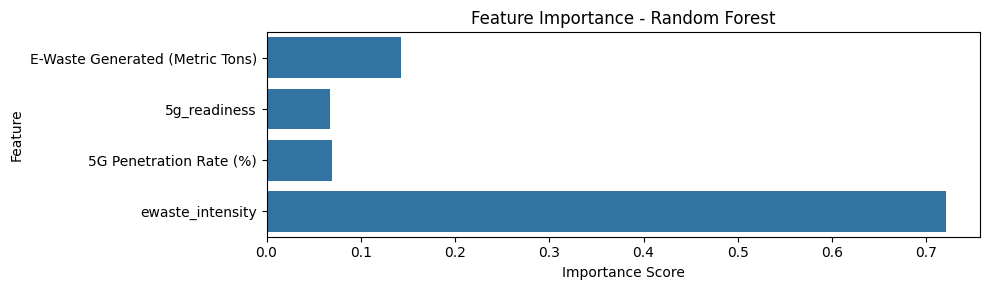

In [374]:
importances = rf_model.feature_importances_  # Assuming rf_best is your optimized RandomForest
features = X_train.columns

# Plot
plt.figure(figsize=(10, 3))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Use case 4

In [375]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# ---------------- Use Case 4: Revenue Prediction ---------------- #

# Define the subset of relevant features
X4 = df[['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)',
         'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)',
         'Average Consumer Spending on Gadgets ($)',
         '5G Penetration Rate (%)', '5g_s_curve_position', '5g_tech_multiplier',
         'device_preference_index', 'spending_per_tech_unit', '5g_readiness',
         'sustainable_tech_score', 'ewaste_intensity', 'E-Waste Generated (Metric Tons)', 'Gadget_Growth_Rate']]

y4 = df['Revenue_per_Gadget']  # 🎯 Target variable

# Feature selection using F-score
selector4 = SelectKBest(score_func=f_regression, k='all')
selector4.fit(X4, y4)

# DataFrame of feature scores and p-values
feature_scores4 = pd.DataFrame({
    'Feature': X4.columns,
    'F-Score': selector4.scores_,
    'P-Value': selector4.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Output
print("\n📊 Use Case 4 - Revenue Prediction: Feature Importance")
print(feature_scores4.to_string(index=False))



📊 Use Case 4 - Revenue Prediction: Feature Importance
                                 Feature      F-Score       P-Value
                  spending_per_tech_unit 1.807401e+07 6.427188e-284
Average Consumer Spending on Gadgets ($) 9.273965e+01  3.236791e-16
                 device_preference_index 4.720301e+01  4.269226e-10
             Smartphone Sales (Millions) 4.053845e+01  4.806557e-09
                        ewaste_intensity 1.846441e+01  3.801686e-05
                      Gadget_Growth_Rate 1.064635e+01  1.476916e-03
                  sustainable_tech_score 5.861194e+00  1.714536e-02
             Laptop Shipments (Millions) 4.358291e+00  3.918153e-02
             Gaming Console Adoption (%) 1.151856e+00  2.855532e-01
         E-Waste Generated (Metric Tons) 3.667251e-01  5.460653e-01
                     5g_s_curve_position 1.016434e-01  7.504821e-01
                      5g_tech_multiplier 9.040793e-02  7.642373e-01
                            5g_readiness 1.476494e-02  9.0351

In [376]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Use the selected top 5 features from feature_scores4
top_5_features = feature_scores4.head(5)['Feature'].tolist()

# Prepare X and y
X_top_5 = df[top_5_features]
y = df['Revenue_per_Gadget']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_top_5, y, test_size=0.2, random_state=42)

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate the model
train_r2_rf = r2_score(y_train, y_train_pred_rf)
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

# Display results
print("\n🌲 Random Forest - Train R² Score:", train_r2_rf)
print("📉 Random Forest - Train Mean Squared Error (MSE):", train_mse_rf)

print("\n🌲 Random Forest - Test R² Score:", test_r2_rf)
print("📉 Random Forest - Test Mean Squared Error (MSE):", test_mse_rf)



🌲 Random Forest - Train R² Score: 0.998339815947883
📉 Random Forest - Train Mean Squared Error (MSE): 0.02517887134935143

🌲 Random Forest - Test R² Score: 0.9931827519913182
📉 Random Forest - Test Mean Squared Error (MSE): 0.0964238026685834


In [377]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Use the best model from GridSearchCV
cv_scores = cross_val_score(rf_model, X_top_5, y, cv=5, scoring='r2')

# Display results
print("📊 Cross-Validation R² Scores:", cv_scores)
print("🔁 Average Cross-Validation R² Score:", np.mean(cv_scores))


📊 Cross-Validation R² Scores: [0.9818652  0.98178336 0.99905195 0.9978885  0.98686306]
🔁 Average Cross-Validation R² Score: 0.9894904157311892


In [378]:
cv_mse_scores = cross_val_score(rf_model, X_top_5, y, cv=5, scoring='neg_mean_squared_error')
print("📉 Cross-Validation MSE Scores (negative):", cv_mse_scores)
print("📉 Average Cross-Validation MSE (positive):", -np.mean(cv_mse_scores))


📉 Cross-Validation MSE Scores (negative): [-0.35207553 -0.39789555 -0.00497386 -0.02840141 -0.16773906]
📉 Average Cross-Validation MSE (positive): 0.19021708123841613


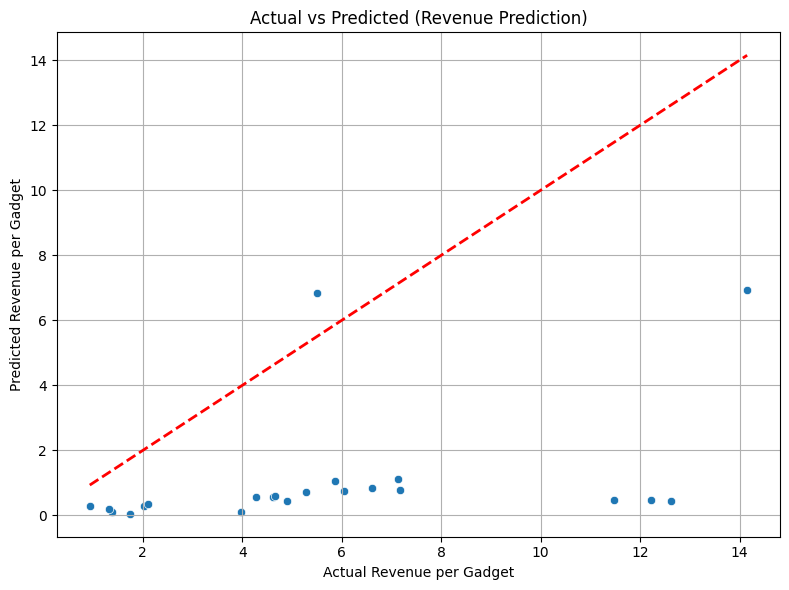

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue per Gadget')
plt.ylabel('Predicted Revenue per Gadget')
plt.title('Actual vs Predicted (Revenue Prediction)')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-380-bf37011cd157>:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-380-bf37011cd157>:17: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



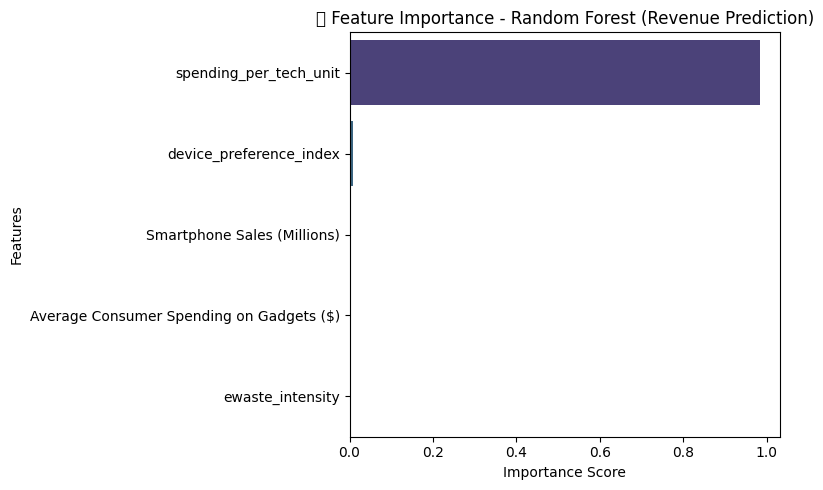

In [380]:
# Get feature importances from best model
importances = rf_model.feature_importances_
feature_names = top_5_features

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('📊 Feature Importance - Random Forest (Revenue Prediction)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [381]:
print("🔎 Length of feature_names:", len(feature_names))
print("🔎 Length of importances:", len(importances))


🔎 Length of feature_names: 5
🔎 Length of importances: 5


In [382]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error

train_r2_lr = r2_score(y_train, y_train_pred_lr)
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)

test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)

# Display results
print("\n📈 Linear Regression - Train R² Score:", train_r2_lr)
print("📉 Linear Regression - Train MSE:", train_mse_lr)
print("\n📈 Linear Regression - Test R² Score:", test_r2_lr)
print("📉 Linear Regression - Test MSE:", test_mse_lr)



📈 Linear Regression - Train R² Score: 0.999999278474189
📉 Linear Regression - Train MSE: 1.0942886450550225e-05

📈 Linear Regression - Test R² Score: 0.9999990911277895
📉 Linear Regression - Test MSE: 1.2855174780372629e-05


<ipython-input-383-8fe97125d582>:11: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



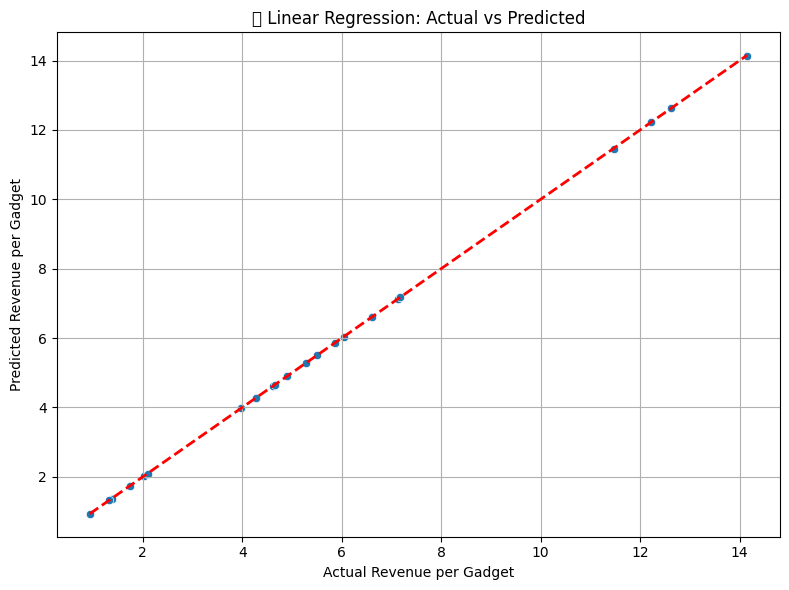

In [383]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue per Gadget')
plt.ylabel('Predicted Revenue per Gadget')
plt.title('📊 Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


In [384]:
# Coefficients and Intercept
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n📋 Linear Regression Coefficients:")
print(coeff_df)

print("\n📍 Intercept:", lr_model.intercept_)



📋 Linear Regression Coefficients:
                                    Feature  Coefficient
0                    spending_per_tech_unit     1.009882
2                   device_preference_index     0.000057
3               Smartphone Sales (Millions)     0.000017
4                          ewaste_intensity     0.000007
1  Average Consumer Spending on Gadgets ($)    -0.000018

📍 Intercept: -0.015337189453131117


In [385]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept)
X_vif = add_constant(X_top_5)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


                                    Feature        VIF
0                                     const  49.975040
1                    spending_per_tech_unit   6.199699
2  Average Consumer Spending on Gadgets ($)   4.221015
3                   device_preference_index  30.518306
4               Smartphone Sales (Millions)  24.186600
5                          ewaste_intensity   1.613676


In [386]:
# Create 3 revenue classes: Low, Medium, High
df['Revenue_Class'] = pd.qcut(df['Revenue_per_Gadget'], q=3, labels=['Low', 'Medium', 'High'])


In [387]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Prepare features (same candidates as before)
X4 = df[['spending_per_tech_unit', 'Average Consumer Spending on Gadgets ($)',
         'device_preference_index', 'Smartphone Sales (Millions)', 'ewaste_intensity',
         'E-Waste Generated (Metric Tons)', '5g_readiness', '5G Penetration Rate (%)',
         'Laptop Shipments (Millions)', 'Smartwatch Penetration (%)', 'Year']]

y4 = df['Revenue_Class']

# Feature selection using f_classif
selector4 = SelectKBest(score_func=f_classif, k='all')
selector4.fit(X4, y4)

# Scores and p-values
feature_scores4 = pd.DataFrame({
    'Feature': X4.columns,
    'F-Score': selector4.scores_,
    'P-Value': selector4.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Display results
print("📊 Use Case 4 - Classification Feature Selection")
print(feature_scores4.to_string(index=False))


📊 Use Case 4 - Classification Feature Selection
                                 Feature    F-Score      P-Value
                  spending_per_tech_unit 115.825718 1.699225e-27
Average Consumer Spending on Gadgets ($)  94.424393 2.343140e-24
                        ewaste_intensity  15.283106 1.450948e-06
                 device_preference_index  13.935216 4.182983e-06
             Smartphone Sales (Millions)  12.152359 1.754020e-05
             Laptop Shipments (Millions)   3.799626 2.545696e-02
                                    Year   2.851294 6.216831e-02
         E-Waste Generated (Metric Tons)   1.046013 3.549002e-01
              Smartwatch Penetration (%)   0.949772 3.900659e-01
                            5g_readiness   0.356271 7.011100e-01
                 5G Penetration Rate (%)   0.320070 7.267912e-01


In [388]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select top 5 features
top_features4 = feature_scores4.head(5)['Feature'].tolist()

# Use only the top 5 selected features
X_cls = df[top_features4]
y_cls = df['Revenue_Class']

# Scale the features
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

# Train-test split (use scaled features)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls)


In [389]:
# Re-train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_cls, y_train_cls)

# Predict again
y_pred_cls = log_model.predict(X_test_cls)

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
print("\n📊 Classification Report:\n", classification_report(y_test_cls, y_pred_cls))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))



📊 Classification Report:
               precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       1.00      1.00      1.00         7
      Medium       0.78      1.00      0.88         7

    accuracy                           0.91        22
   macro avg       0.93      0.92      0.91        22
weighted avg       0.93      0.91      0.91        22


🧩 Confusion Matrix:
 [[6 0 2]
 [0 7 0]
 [0 0 7]]


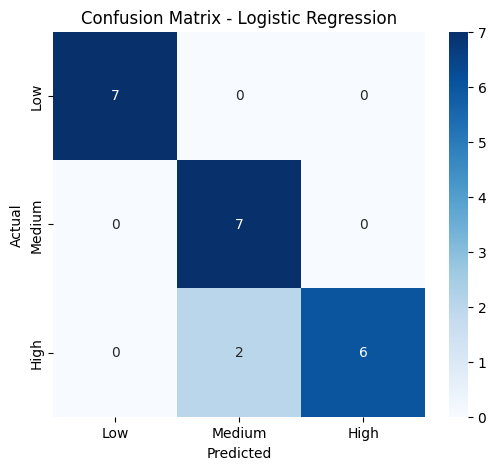

In [390]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=['Low', 'Medium', 'High'])

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [391]:
# Predictions on training data
y_train_pred_cls = log_model.predict(X_train_cls)

# Evaluation on training set
from sklearn.metrics import accuracy_score, classification_report

print("🔵 Train Set Evaluation")
print("Accuracy:", accuracy_score(y_train_cls, y_train_pred_cls))
print(classification_report(y_train_cls, y_train_pred_cls))

# Already done earlier for test, but repeat for completeness
print("\n🟢 Test Set Evaluation")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print(classification_report(y_test_cls, y_pred_cls))


🔵 Train Set Evaluation
Accuracy: 0.9545454545454546
              precision    recall  f1-score   support

        High       1.00      0.90      0.95        29
         Low       1.00      0.97      0.98        30
      Medium       0.88      1.00      0.94        29

    accuracy                           0.95        88
   macro avg       0.96      0.95      0.95        88
weighted avg       0.96      0.95      0.95        88


🟢 Test Set Evaluation
Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       1.00      1.00      1.00         7
      Medium       0.78      1.00      0.88         7

    accuracy                           0.91        22
   macro avg       0.93      0.92      0.91        22
weighted avg       0.93      0.91      0.91        22



In [392]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# ---------------- Step 1: Define Features & Target ---------------- #
X_rf = df[['spending_per_tech_unit',
           'Average Consumer Spending on Gadgets ($)',
           'device_preference_index',
           'Smartphone Sales (Millions)',
           'ewaste_intensity']]

y_rf = df['Revenue_Class']

# ---------------- Step 2: Train-Test Split ---------------- #
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# ---------------- Step 3: Train Random Forest Classifier ---------------- #
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_rf, y_train_rf)

# ---------------- Step 4: Predictions ---------------- #
y_train_pred_rf = rf_classifier.predict(X_train_rf)
y_test_pred_rf = rf_classifier.predict(X_test_rf)

# ---------------- Step 5: Evaluation ---------------- #
print("🔵 Train Set Evaluation")
print("Accuracy:", accuracy_score(y_train_rf, y_train_pred_rf))
print(classification_report(y_train_rf, y_train_pred_rf))

print("\n🟢 Test Set Evaluation")
print("Accuracy:", accuracy_score(y_test_rf, y_test_pred_rf))
print(classification_report(y_test_rf, y_test_pred_rf))


🔵 Train Set Evaluation
Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        28
         Low       1.00      1.00      1.00        31
      Medium       1.00      1.00      1.00        29

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88


🟢 Test Set Evaluation
Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00         6
      Medium       1.00      1.00      1.00         7

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



<ipython-input-393-19c9b50e48df>:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-393-19c9b50e48df>:20: UserWarning:

Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.



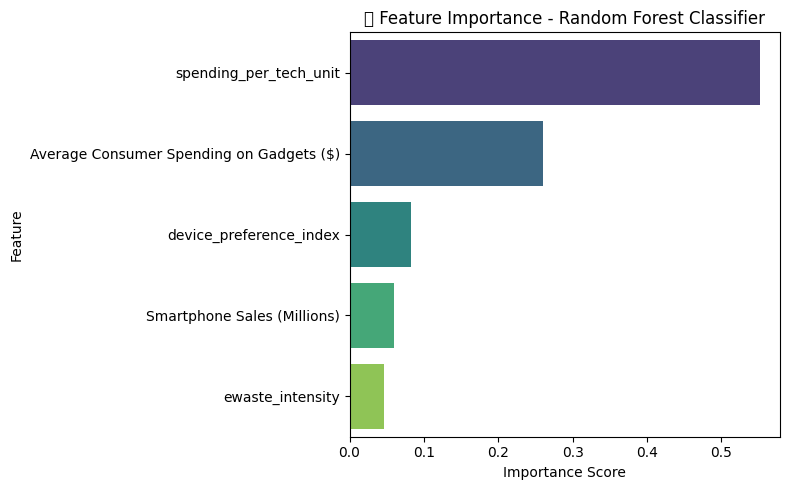

In [393]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = rf_classifier.feature_importances_
feature_names = X_rf.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('📌 Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



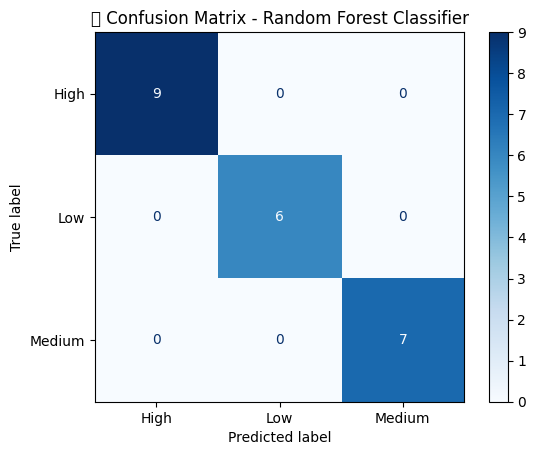

In [394]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
y_pred_rf = rf_classifier.predict(X_test_rf)

# Compute confusion matrix
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=rf_classifier.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_classifier.classes_)
disp.plot(cmap='Blues')
plt.title("📊 Confusion Matrix - Random Forest Classifier")
plt.show()


In [395]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_classifier, X_rf, y_rf, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())


Cross-validation scores: [1.         0.90909091 0.95454545 1.         1.        ]
Average CV accuracy: 0.9727272727272727
